# Stock Price Prediction 
---
**Структура на Проектот:**
1.  Вчитување и прва инспекција на датасетот
2.  Длабока EDA (Exploratory Data Analysis)
3.  Детекција и обработка на Outliers (IQR + Z-Score)
4.  Preprocessing — Window Size, Feature Engineering, Скалирање
5.  Корелациска анализа
6.  Train/Test Split (хронолошки)
7.  Тренирање на ML Модели (RF, KNN, SVM, XGBoost)
8.  Временска Серија — ARIMA
9.  Длабоко учење — LSTM
10. Евалуација и споредба на сите модели
11. Анализа на перформансите во тест периодот (Јануари 2024)

##  1. Вчитување на библиотеки

In [142]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import time


import random
def set_all_seeds(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from statsmodels.tsa.arima.model import ARIMA
import time


from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor


from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler as SS


set_all_seeds(42)


plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("tab10")

print("✅ Сите библиотеки се успешно вчитани.")
print(f"   TensorFlow верзија: {tf.__version__}")   
print(f"   NumPy верзија:      {np.__version__}")
print(f"   Pandas верзија:     {pd.__version__}")


✅ Сите библиотеки се успешно вчитани.
   TensorFlow верзија: 2.21.0
   NumPy верзија:      2.3.4
   Pandas верзија:     2.3.3


##  2. Вчитување и прва анализа на датасетот

In [143]:

base_dir = os.getcwd()
stocks_path = os.path.join(base_dir, '..', 'data', 'raw', 'sp500_stocks.csv')
index_path = os.path.join(base_dir, '..', 'data', 'raw', 'sp500_index.csv')
companies_path = os.path.join(base_dir, '..', 'data', 'raw', 'sp500_companies.csv')


df_stocks_raw = pd.read_csv(stocks_path)
df_index_raw = pd.read_csv(index_path)
df_companies_raw = pd.read_csv(companies_path)

print(" Сите три CSV фајлови се успешно вчитани во меморијата.")

 Сите три CSV фајлови се успешно вчитани во меморијата.


Вчитување на sp500_companies.csv

In [144]:
print("=== Вчитување НА COMPANIES ДАТАСЕТОТ ===")
print(f"Димензии: {df_companies_raw.shape[0]} компании и {df_companies_raw.shape[1]} мета-колони.\n")
print("Првите 3 реда од табелата:")
display(df_companies_raw.head(3))

print("\nКолони кои се достапни за компаниите:")
print(df_companies_raw.columns.tolist())

=== Вчитување НА COMPANIES ДАТАСЕТОТ ===
Димензии: 502 компании и 16 мета-колони.

Првите 3 реда од табелата:


,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,City,State,Country,Fulltimeemployees,Longbusinesssummary,Weight
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.346610e+11,0.061,Cupertino,CA,United States,164000.0,"Apple Inc. designs, manufactures, and markets ...",0.069209
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118400e+10,1.224,Santa Clara,CA,United States,29600.0,NVIDIA Corporation provides graphics and compu...,0.059350
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.365520e+11,0.160,Redmond,WA,United States,228000.0,Microsoft Corporation develops and supports so...,0.058401



Колони кои се достапни за компаниите:
['Exchange', 'Symbol', 'Shortname', 'Longname', 'Sector', 'Industry', 'Currentprice', 'Marketcap', 'Ebitda', 'Revenuegrowth', 'City', 'State', 'Country', 'Fulltimeemployees', 'Longbusinesssummary', 'Weight']


Анализа на sp500_index.csv

In [145]:
print("=== Вчитување НА S&P 500 INDEX ДАТАСЕТОТ ===")
print(f"Димензии: {df_index_raw.shape[0]} работни денови на берзата.\n")
print("Првите 5 денови од историјата на индексот:")
display(df_index_raw.head(5))


print("\nОсновна статистика за вредноста на индексот:")
display(df_index_raw.describe())

=== Вчитување НА S&P 500 INDEX ДАТАСЕТОТ ===
Димензии: 2517 работни денови на берзата.

Првите 5 денови од историјата на индексот:


,Date,S&P500
0,2014-12-22,2078.54
1,2014-12-23,2082.17
2,2014-12-24,2081.88
3,2014-12-26,2088.77
4,2014-12-29,2090.57



Основна статистика за вредноста на индексот:


,S&P500
count,2517.000000
mean,3346.351605
std,1078.204274
min,1829.080000
25%,2428.370000
50%,2999.910000
75%,4199.120000
max,6090.270000


Вчитување на sp500_stocks.csv

In [146]:
print("=== Вчитување НА ГЛАВНИОТ STOCKS ДАТАСЕТ ===")
print(f"Вкупен број на записи за сите акции: {df_stocks_raw.shape[0]:,}")
print(f"Број на колони: {df_stocks_raw.shape[1]}\n")

print("🔍 Детекција на недостапни (NaN) вредности во овој огромен фајл:")
nan_counts = df_stocks_raw.isnull().sum()
display(nan_counts[nan_counts > 0])

print("\nПример од првите 5 редови во табелата:")
display(df_stocks_raw.head(5))

=== Вчитување НА ГЛАВНИОТ STOCKS ДАТАСЕТ ===
Вкупен број на записи за сите акции: 1,891,536
Број на колони: 8

🔍 Детекција на недостапни (NaN) вредности во овој огромен фајл:


Adj Close    1273705
Close        1273705
High         1273705
Low          1273705
Open         1273705
Volume       1273705
dtype: int64


Пример од првите 5 редови во табелата:


,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,MMM,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,MMM,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,MMM,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,MMM,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,MMM,NaN,NaN,NaN,NaN,NaN,NaN


In [147]:
df_stocks_raw[df_stocks_raw['Close'].notna()]

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
3768,2010-01-04,AOS,5.937266,7.435000,7.480000,7.261667,7.295000,1104600.0
3769,2010-01-05,AOS,5.861404,7.340000,7.431667,7.308333,7.431667,1207200.0
3770,2010-01-06,AOS,5.864068,7.343333,7.405000,7.301667,7.335000,663000.0
3771,2010-01-07,AOS,5.881369,7.365000,7.425000,7.311667,7.356667,564000.0
3772,2010-01-08,AOS,5.967879,7.473333,7.485000,7.311667,7.331667,504600.0
...,...,...,...,...,...,...,...,...
1876459,2024-12-16,XYL,120.779999,120.779999,122.570000,120.000000,120.720001,1515900.0
1876460,2024-12-17,XYL,120.769997,120.769997,121.760002,119.730003,119.730003,2009200.0
1876461,2024-12-18,XYL,116.919998,116.919998,121.559998,116.879997,120.790001,1638500.0
1876462,2024-12-19,XYL,116.430000,116.430000,118.919998,116.129997,117.440002,1708000.0


Филтрирање и спојување на податоците 

✅ Најдени 3,768 записи за EIX (2010-01-04 → 2024-12-20)
🎉 Успешно креиран споениот сет податоци за EIX!

  ИНФОРМАЦИИ ЗА ДАТАСЕТОТ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2517 non-null   datetime64[ns]
 1   Symbol     2517 non-null   object        
 2   Adj Close  2517 non-null   float64       
 3   Close      2517 non-null   float64       
 4   High       2517 non-null   float64       
 5   Low        2517 non-null   float64       
 6   Open       2517 non-null   float64       
 7   Volume     2517 non-null   float64       
 8   S&P500     2517 non-null   float64       
 9   Longname   2517 non-null   object        
 10  Sector     2517 non-null   object        
dtypes: datetime64[ns](1), float64(7), object(3)
memory usage: 216.4+ KB

  ПРЕОСТАНАТИ MISSING VALUES
✅ Нема missing values!

  ДЕСКРИПТИВНА СТАТИСТИК

,Date,Adj Close,Close,High,Low,Open,Volume,S&P500
count,2517,2517.0000,2517.0000,2517.0000,2517.0000,2517.0000,2.517000e+03,2517.0000
mean,2019-12-22 08:34:53.921335040,55.0205,66.8059,67.4339,66.1291,66.7923,2.143654e+06,3346.3516
min,2014-12-22 00:00:00,36.0499,44.4700,48.4200,43.6300,46.3300,3.823000e+05,1829.0800
25%,2017-06-22 00:00:00,47.8499,60.4900,61.0300,59.8700,60.4600,1.456500e+06,2428.3700
50%,2019-12-20 00:00:00,52.9796,66.4500,67.1800,65.6400,66.3600,1.864200e+06,2999.9100
75%,2022-06-22 00:00:00,60.2688,71.8100,72.3400,71.2400,71.8200,2.467800e+06,4199.1200
max,2024-12-20 00:00:00,88.3600,88.3600,88.7700,87.7700,88.3900,2.611920e+07,6090.2700
std,NaN,9.8443,7.9442,7.8683,8.0033,7.9488,1.275096e+06,1078.2043


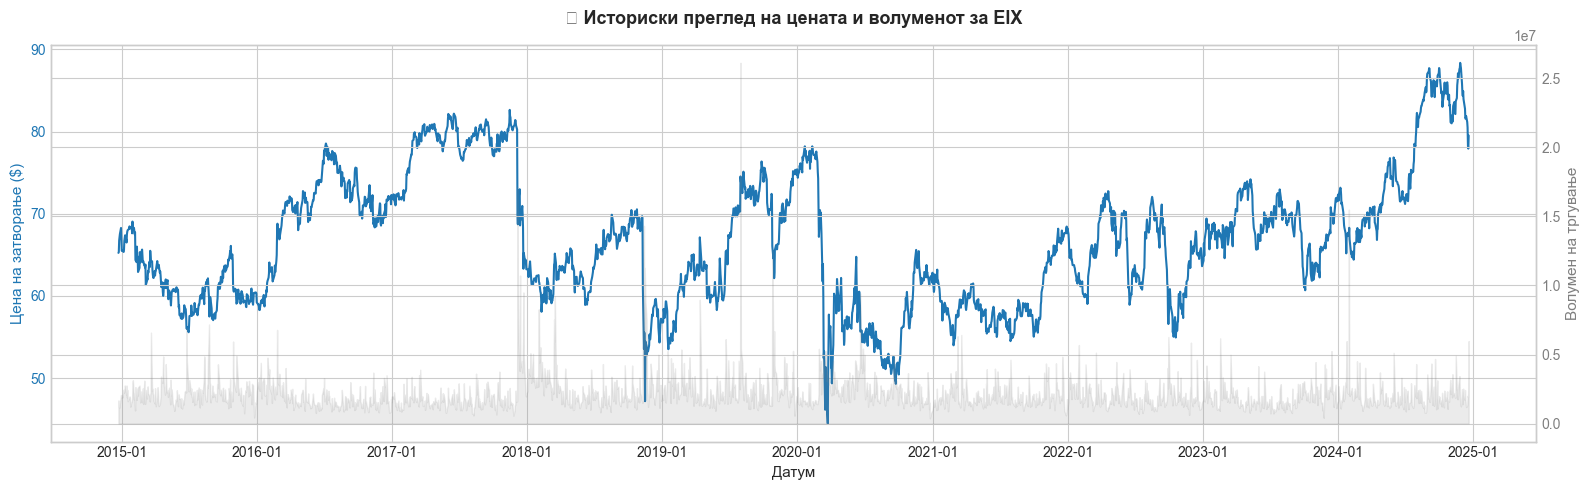

In [148]:

TICKER = 'EIX'

df_stocks_raw.columns = df_stocks_raw.columns.str.strip()
df_stocks_raw.dropna(subset=['Symbol'], inplace=True)
df_stocks_raw['Symbol'] = df_stocks_raw['Symbol'].astype(str).str.strip()


df = df_stocks_raw[df_stocks_raw['Symbol'].str.upper() == TICKER.upper()].copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)


df.dropna(subset=['Close'], inplace=True)


if df.empty:
    raise ValueError(
        f"\n❌ ГРЕШКА: Нема податоци за тикерот '{TICKER}'.\n"
        f"   Провери дали тикерот е точно напишан (пример: 'AAPL', 'MSFT', 'TSLA').\n"
        f"   Ако е точен, можно е компанијата да нема историски податоци во датасетот."
    )
else:
    print(f"✅ Најдени {len(df):,} записи за {TICKER} ({df['Date'].min().date()} → {df['Date'].max().date()})")


df_index_raw['Date'] = pd.to_datetime(df_index_raw['Date'])
df = pd.merge(df, df_index_raw, on='Date', how='left', suffixes=('', '_index'))

df_companies_raw['Symbol'] = df_companies_raw['Symbol'].astype(str).str.strip()
df = pd.merge(df, df_companies_raw[['Symbol', 'Longname', 'Sector']], on='Symbol', how='left')


df.dropna(subset=['S&P500'], inplace=True)


df.reset_index(drop=True, inplace=True)

print(f"🎉 Успешно креиран споениот сет податоци за {TICKER}!\n")


print("=" * 60)
print("  ИНФОРМАЦИИ ЗА ДАТАСЕТОТ")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("  ПРЕОСТАНАТИ MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Бројка': missing, 'Процент (%)': missing_pct})
print(missing_df[missing_df['Бројка'] > 0] if missing.sum() > 0 else "✅ Нема missing values!")

print("\n" + "=" * 60)
print("  ДЕСКРИПТИВНА СТАТИСТИКА")
print("=" * 60)
display(df.describe().round(4))


fig, ax1 = plt.subplots(figsize=(16, 5))


color = 'tab:blue'
ax1.set_xlabel('Датум', fontsize=11)
ax1.set_ylabel('Цена на затворање ($)', color=color, fontsize=11)
ax1.plot(df['Date'], df['Close'], color=color, linewidth=1.5, label='Close цена')
ax1.tick_params(axis='y', labelcolor=color)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))


ax2 = ax1.twinx()  
color = 'tab:gray'
ax2.set_ylabel('Волумен на тргување', color=color, fontsize=11)
ax2.fill_between(df['Date'], df['Volume'], color=color, alpha=0.15, label='Волумен')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f"📈 Историски преглед на цената и волуменот за {TICKER}", fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

##  3. Длабока EDA (Exploratory Data Analysis)



Историски тренд на цена и волумен

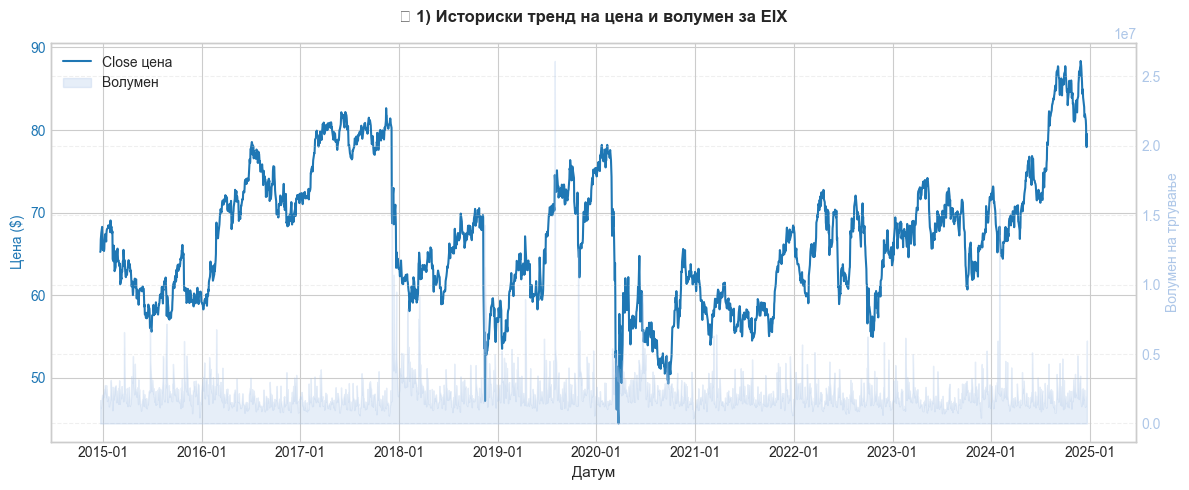

In [149]:

fig, ax1 = plt.subplots(figsize=(12, 5))


color = '#1f77b4'
ax1.set_xlabel('Датум', fontsize=11)
ax1.set_ylabel('Цена ($)', color=color)
p1, = ax1.plot(df['Date'], df['Close'], color=color, linewidth=1.5, label='Close цена')
ax1.tick_params(axis='y', labelcolor=color)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

ax2 = ax1.twinx()
color = '#aec7e8'
ax2.set_ylabel('Волумен на тргување', color=color)
p2 = ax2.fill_between(df['Date'], df['Volume'], color=color, alpha=0.3, label='Волумен')
ax2.tick_params(axis='y', labelcolor=color)


ax1.legend([p1, p2], [p1.get_label(), p2.get_label()], loc='upper left', fontsize=10)

plt.title(f'📈 1) Историски тренд на цена и волумен за {TICKER}', fontsize=12, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Дистрибуција на цената (Хистограм)

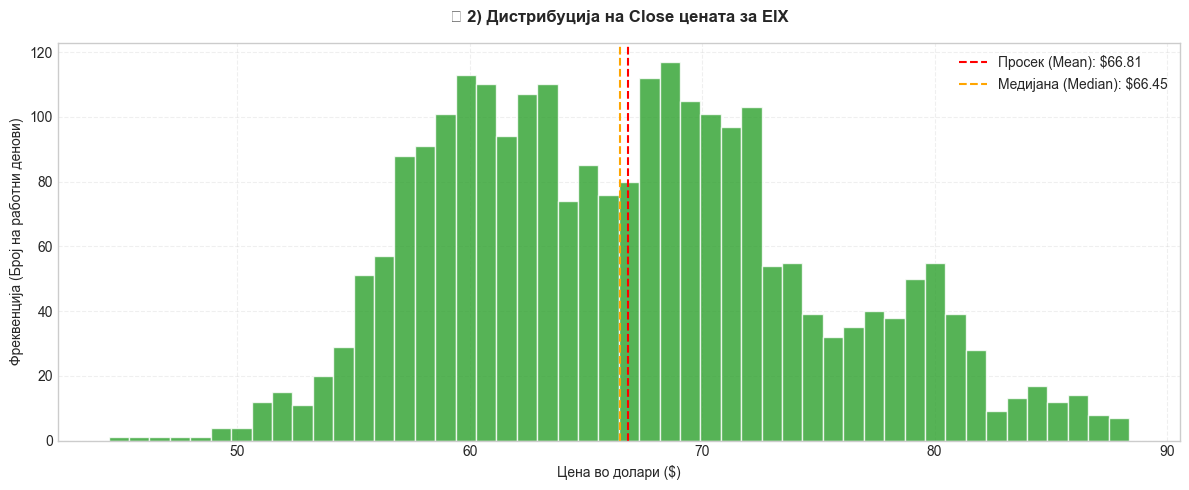

In [150]:

plt.figure(figsize=(12, 5))


plt.hist(df['Close'], bins=50, color='#2ca02c', edgecolor='white', alpha=0.8)


plt.axvline(df['Close'].mean(), color='red', linestyle='--', linewidth=1.5, 
            label=f"Просек (Mean): ${df['Close'].mean():.2f}")
plt.axvline(df['Close'].median(), color='orange', linestyle='--', linewidth=1.5, 
            label=f"Медијана (Median): ${df['Close'].median():.2f}")

plt.title(f'📊 2) Дистрибуција на Close цената за {TICKER}', fontsize=12, fontweight='bold', pad=15)
plt.legend(fontsize=10)
plt.xlabel('Цена во долари ($)')
plt.ylabel('Фреквенција (Број на работни денови)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Годишен просек на цената

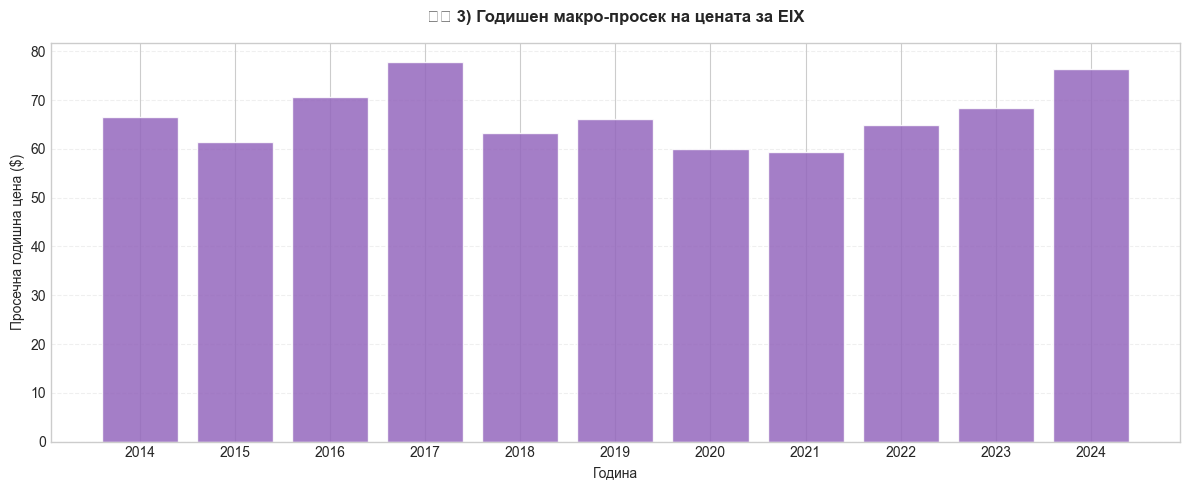

In [151]:

df['Year'] = df['Date'].dt.year
yearly = df.groupby('Year')['Close'].mean()


plt.figure(figsize=(12, 5))
plt.bar(yearly.index.astype(str), yearly.values, color='#9467bd', edgecolor='white', alpha=0.85)

plt.title(f'🏛️ 3) Годишен макро-просек на цената за {TICKER}', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Година')
plt.ylabel('Просечна годишна цена ($)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Бришење на привремената колона за да не го валкаме датасетот
df.drop(columns=['Year'], inplace=True, errors='ignore')

plt.tight_layout()
plt.show()

Сезонски просек по месеци (Seasonality)

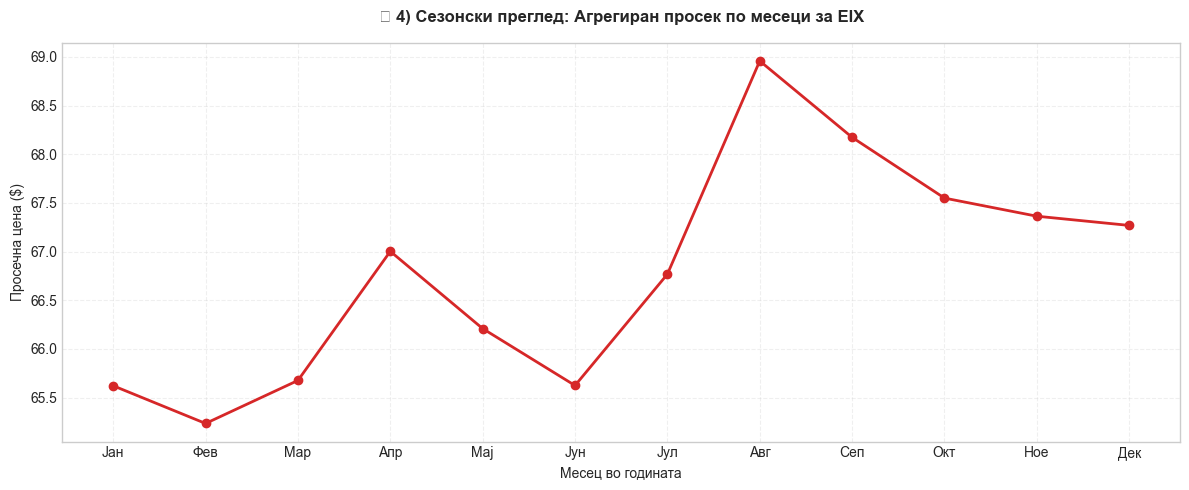

In [152]:

df['Month'] = df['Date'].dt.month
monthly = df.groupby('Month')['Close'].mean()
months_labels = ['Јан','Фев','Мар','Апр','Мај','Јун','Јул','Авг','Сеп','Окт','Ное','Дек']


plt.figure(figsize=(12, 5))
plt.plot(range(1, 13), monthly.values, marker='o', color='#d62728', linewidth=2, markersize=6)

plt.title(f'📅 4) Сезонски преглед: Агрегиран просек по месеци за {TICKER}', fontsize=12, fontweight='bold', pad=15)
plt.xticks(range(1, 13), months_labels, fontsize=10)
plt.xlabel('Месец во годината')
plt.ylabel('Просечна цена ($)')
plt.grid(True, linestyle='--', alpha=0.3)


df.drop(columns=['Month'], inplace=True, errors='ignore')

plt.tight_layout()
plt.show()

Пресметка на приноси

In [153]:
df['Daily_Return_Raw'] = df['Close'].pct_change()


returns_pct = df['Daily_Return_Raw'].dropna() * 100

print(" Дневните приноси се успешно пресметани!")

 Дневните приноси се успешно пресметани!


Дистрибуција на приноси

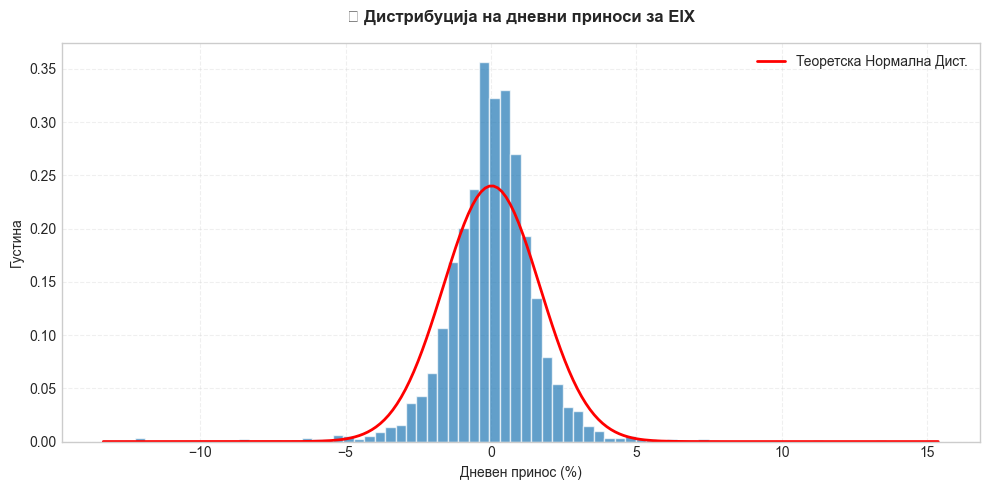

In [154]:
plt.figure(figsize=(10, 5))


plt.hist(returns_pct, bins=80, color='#1f77b4', edgecolor='white', alpha=0.7, density=True)


mu_pct, sigma_pct = returns_pct.mean(), returns_pct.std()
x = np.linspace(returns_pct.min(), returns_pct.max(), 200)
plt.plot(x, stats.norm.pdf(x, mu_pct, sigma_pct), 'r-', linewidth=2, label='Теоретска Нормална Дист.')

plt.title(f'📉 Дистрибуција на дневни приноси за {TICKER}', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Дневен принос (%)')
plt.ylabel('Густина')
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Boxplot и Ролинг Волатилност

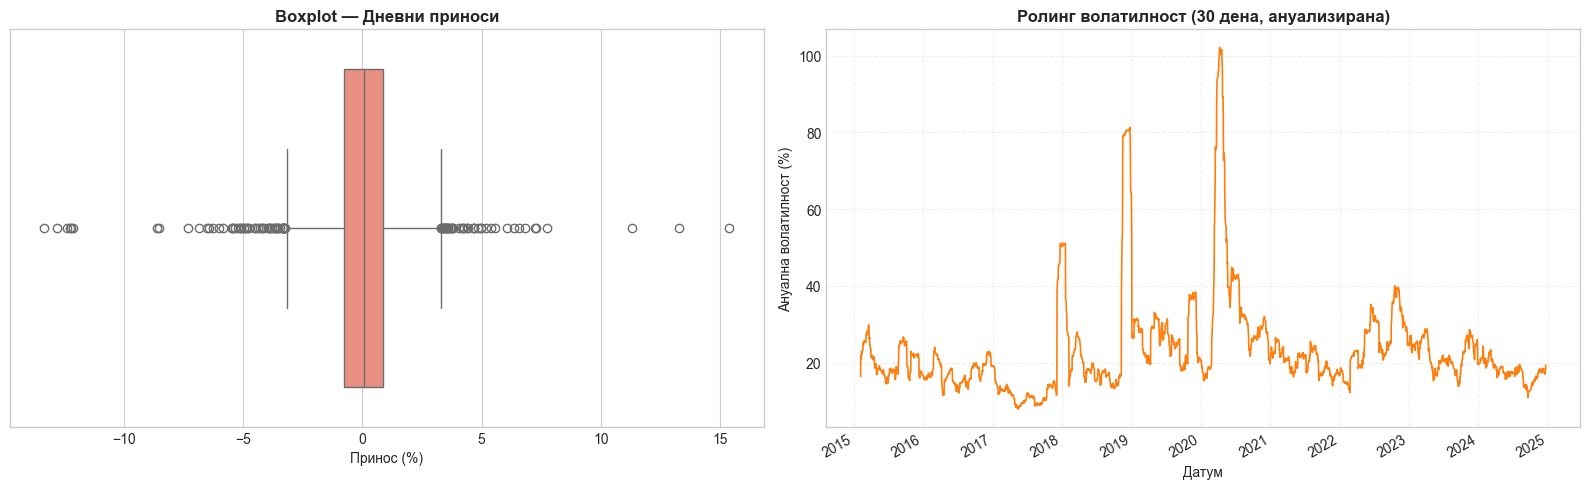

In [155]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))


sns.boxplot(x=returns_pct, ax=ax1, color='salmon')
ax1.set_title('Boxplot — Дневни приноси', fontweight='bold')
ax1.set_xlabel('Принос (%)')


rolling_vol = df['Daily_Return_Raw'].rolling(30).std() * np.sqrt(252) * 100
ax2.plot(df['Date'], rolling_vol, color='#ff7f0e', linewidth=1.2, label='30д Ролинг Волатилност')
ax2.set_title('Ролинг волатилност (30 дена, ануализирана)', fontweight='bold')
ax2.set_xlabel('Датум')
ax2.set_ylabel('Ануална волатилност (%)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Статистички бројки и пополнување на дупки

In [156]:

df['Daily_Return_Raw'] = df['Daily_Return_Raw'].fillna(0)

print(f"=" * 50)
print(f" ДЕСКРИПТИВНА СТАТИСТИКА НА ДНЕВНИТЕ ПРИНОСИ")
print(f"=" * 50)
print(f"   Просечен дневен принос:  {mu_pct:.4f}%")
print(f"   Стандардна девијација:   {sigma_pct:.4f}%")
print(f"   Skewness (асиметрија):   {returns_pct.skew():.4f}")
print(f"   Kurtosis:     {returns_pct.kurtosis():.4f}")
print(f"=" * 50)

 ДЕСКРИПТИВНА СТАТИСТИКА НА ДНЕВНИТЕ ПРИНОСИ
   Просечен дневен принос:  0.0218%
   Стандардна девијација:   1.6615%
   Skewness (асиметрија):   -0.5365
   Kurtosis:     14.3094


##  4. Детекција и обработка на Outliers

Математичка пресметка и детекција (IQR и Z-Score).


In [157]:

returns_pct = df['Daily_Return_Raw'] * 100


Q1 = returns_pct.quantile(0.25)
Q3 = returns_pct.quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

outliers_iqr_idx = (returns_pct < lower_iqr) | (returns_pct > upper_iqr)
outliers_iqr = df[outliers_iqr_idx]


z_scores = np.abs(stats.zscore(df['Daily_Return_Raw']))
outliers_zscore = df[z_scores > 3]

print("=" * 60)
print("  РЕЗУЛТАТИ ОД ДЕТЕКЦИЈА НА OUTLIERS")
print("=" * 60)
print(f"IQR Метод       — Граници: [{lower_iqr:.2f}%, {upper_iqr:.2f}%]")
print(f"                — Пронајдени аутлаери: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}%)")
print(f"Z-Score (>3σ)  — Пронајдени аутлаери: {len(outliers_zscore)} ({len(outliers_zscore)/len(df)*100:.2f}%)")
print("=" * 60)

  РЕЗУЛТАТИ ОД ДЕТЕКЦИЈА НА OUTLIERS
IQR Метод       — Граници: [-3.20%, 3.30%]
                — Пронајдени аутлаери: 99 (3.93%)
Z-Score (>3σ)  — Пронајдени аутлаери: 37 (1.47%)


Визуелизација на аномалиите (Scatter Plots)

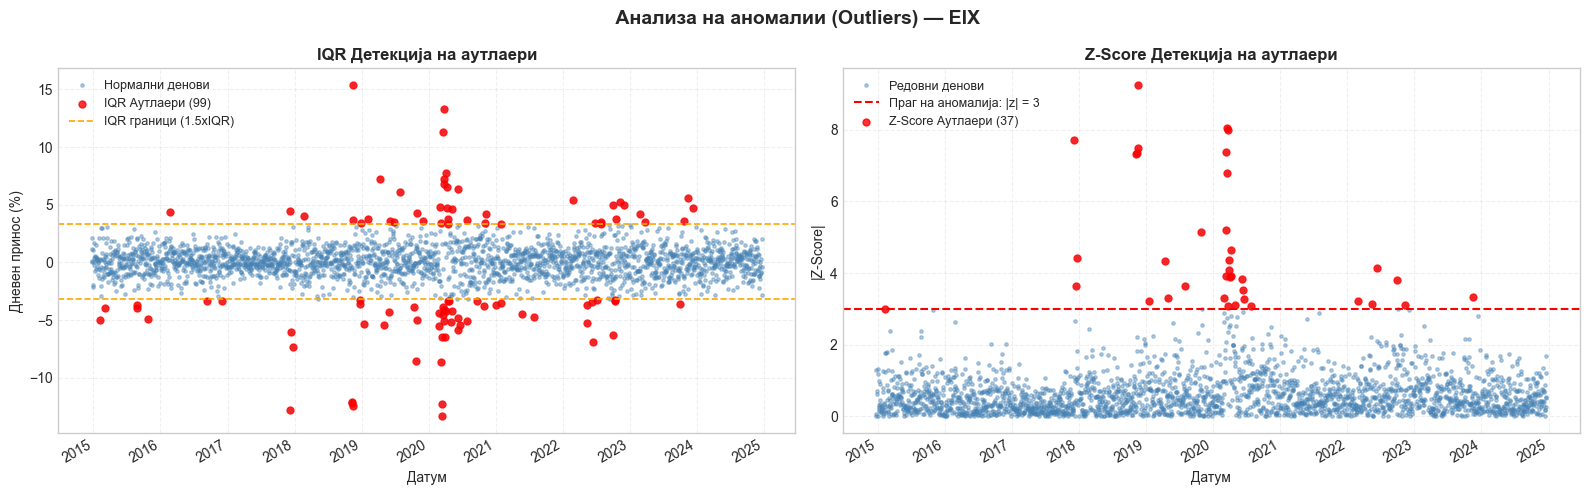

In [158]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f' Анализа на аномалии (Outliers) — {TICKER}', fontsize=14, fontweight='bold', y=0.98)


ax1 = axes[0]
ax1.scatter(df['Date'], returns_pct, s=6, color='steelblue', alpha=0.4, label='Нормални денови')
ax1.scatter(outliers_iqr['Date'], outliers_iqr['Daily_Return_Raw']*100, s=25, color='red', alpha=0.8, label=f'IQR Аутлаери ({len(outliers_iqr)})')
ax1.axhline(lower_iqr, color='orange', linestyle='--', linewidth=1.2, label='IQR граници (1.5xIQR)')
ax1.axhline(upper_iqr, color='orange', linestyle='--', linewidth=1.2)
ax1.set_title('IQR Детекција на аутлаери', fontweight='bold')
ax1.set_xlabel('Датум')
ax1.set_ylabel('Дневен принос (%)')
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')


ax2 = axes[1]
ax2.scatter(df['Date'], z_scores, s=6, color='steelblue', alpha=0.4, label='Редовни денови')
ax2.axhline(3, color='red', linestyle='--', linewidth=1.5, label='Праг на аномалија: |z| = 3')
ax2.scatter(df.loc[z_scores > 3, 'Date'], z_scores[z_scores > 3], s=25, color='red', alpha=0.8, label=f'Z-Score Аутлаери ({len(outliers_zscore)})')
ax2.set_title('Z-Score Детекција на аутлаери', fontweight='bold')
ax2.set_xlabel('Датум')
ax2.set_ylabel('|Z-Score|')
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

Топ 10 Најлуди денови во историјата на Тесла

In [159]:
print("\n Топ 10 денови со најекстремни пазарни движења:")
top_outliers = outliers_iqr.copy()
top_outliers['Daily_Return (%)'] = (top_outliers['Daily_Return_Raw'] * 100).round(2)
top_outliers['|Return (%)|'] = top_outliers['Daily_Return (%)'].abs()


display(top_outliers.sort_values('|Return (%)|', ascending=False)
        [['Date', 'Close', 'Volume', 'Daily_Return (%)']]
        .head(10).reset_index(drop=True))

print("\n Забелешка: Пронајдените аутлаери НЕ СЕ бришат од датасетот со цел да се зачува")
print("   хронолошкиот континуитет и интегритетот на временската серија.")


 Топ 10 денови со најекстремни пазарни движења:


,Date,Close,Volume,Daily_Return (%)
0,2018-11-16,54.450001,8828700.0,15.38
1,2020-03-16,46.150002,4654000.0,-13.33
2,2020-03-24,50.380001,2995100.0,13.29
3,2017-12-05,70.000000,17110000.0,-12.78
4,2018-11-15,47.189999,10222800.0,-12.40
5,2020-03-12,52.430000,4432200.0,-12.24
6,2018-11-12,53.560001,14318800.0,-12.20
7,2018-11-09,61.000000,8044100.0,-12.12
8,2020-03-17,51.360001,4838500.0,11.29
9,2020-03-09,61.759998,3728300.0,-8.63



 Забелешка: Пронајдените аутлаери НЕ СЕ бришат од датасетот со цел да се зачува
   хронолошкиот континуитет и интегритетот на временската серија.


### 4.1 Обработка на Outliers — Capping (Winsorization)

Примена на Capping (Винзоризација)

In [160]:

q1_raw = df['Daily_Return_Raw'].quantile(0.25)
q3_raw = df['Daily_Return_Raw'].quantile(0.75)
iqr_raw = q3_raw - q1_raw
lower_raw = q1_raw - 1.5 * iqr_raw
upper_raw = q3_raw + 1.5 * iqr_raw


df['Daily_Return_Cleaned'] = df['Daily_Return_Raw'].clip(lower=lower_raw, upper=upper_raw)


cleaned_pct = df['Daily_Return_Cleaned'] * 100
lower_pct = lower_raw * 100
upper_pct = upper_raw * 100

print(f" Capping (Winsorization) успешно применет врз приносите.")
print(f"   Математички граници за моделите: [{lower_raw:.4f}, {upper_raw:.4f}]")
print(f"   Визуелни граници во проценти:     [{lower_pct:.2f}%, {upper_pct:.2f}%]")

 Capping (Winsorization) успешно применет врз приносите.
   Математички граници за моделите: [-0.0320, 0.0330]
   Визуелни граници во проценти:     [-3.20%, 3.30%]


Верификација на исчистените податоци (Графикони)

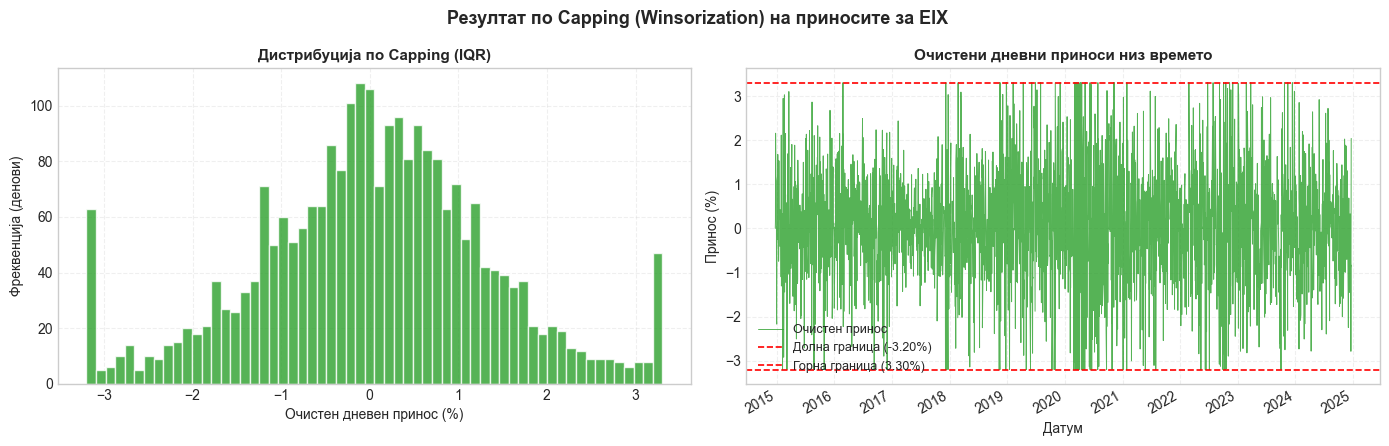

In [161]:



fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle(f' Резултат по Capping (Winsorization) на приносите за {TICKER}', fontsize=13, fontweight='bold', y=0.98)


axes[0].hist(cleaned_pct, bins=60, color='#2ca02c', edgecolor='white', alpha=0.8)
axes[0].set_title('Дистрибуција по Capping (IQR)', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Очистен дневен принос (%)')
axes[0].set_ylabel('Фреквенција (денови)')
axes[0].grid(True, linestyle='--', alpha=0.3)


axes[1].plot(df['Date'], cleaned_pct, color='#2ca02c', linewidth=0.7, alpha=0.8, label='Очистен принос')
axes[1].axhline(lower_pct, color='red', linestyle='--', linewidth=1.2, label=f'Долна граница ({lower_pct:.2f}%)')
axes[1].axhline(upper_pct, color='red', linestyle='--', linewidth=1.2, label=f'Горна граница ({upper_pct:.2f}%)')
axes[1].set_title('Очистени дневни приноси низ времето', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Датум')
axes[1].set_ylabel('Принос (%)')
axes[1].legend(fontsize=9, loc='lower left')
axes[1].grid(True, linestyle='--', alpha=0.3)


axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

##  5. Preprocessing — Window Size & Feature Engineering

**Window Size** е клучен хиперпараметар кај временски серии. Се однесува на 
бројот на минати денови кои ги гледаме за да го предвидиме наредниот ден.

**Вклучени карактеристики:**
- Подвижни просеци (SMA) и EMA за краткорочен и долгорочен тренд
- MACD spread (разлика на EMA за сигнали за влез/излез)
- RSI (индикатор за прекупеност / препродаденост)
- Bollinger Bands width (мерка на волатилност)
- Price momentum (моментум на движење)
- Волатилност (ролинг стандардна девијација)


In [162]:


def create_features_clean(df_input):
    df = df_input.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
   
    df['Close_Lag1'] = df['Close'].shift(1)
    df['Close_Lag2'] = df['Close'].shift(2)
    
    # Моментум
    df['Momentum_5'] = df['Close_Lag1'] - df['Close'].shift(6)
    df['Momentum_10'] = df['Close_Lag1'] - df['Close'].shift(11)
    
  
    df['MA_5'] = df['Close_Lag1'].rolling(window=5).mean()
    df['MA_20'] = df['Close_Lag1'].rolling(window=20).mean()
    df['MA_Trend_Diff'] = df['MA_5'] - df['MA_20']
    
 
    df['EMA_12'] = df['Close_Lag1'].ewm(span=12, adjust=False).mean()
    df['EMA_26'] = df['Close_Lag1'].ewm(span=26, adjust=False).mean()
    df['EMA_Spread'] = df['EMA_12'] - df['EMA_26']
    
  
    std_20 = df['Close_Lag1'].rolling(window=20).std()
    df['BB_Width'] = (std_20 * 4) / (df['MA_20'] + 1e-9)
    df['Volatility_7'] = df['Close_Lag1'].rolling(window=7).std()
    
    
    delta = df['Close_Lag1'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-9)
    df['RSI'] = 100 - (100 / (1 + rs))
    
    
    df['Target_Price'] = df['Close']
    
    df = df.dropna().reset_index(drop=True)
    return df


df_features = create_features_clean(df)


df_ml = df_features


EXCLUDE_COLS = ['Date', 'Symbol', 'Longname', 'Sector', 'Close', 'Target_Price',
                'Open', 'High', 'Low', 'Volume', 'Adj Close', 'S&P500',
                'Daily_Return_Raw', 'Daily_Return_Cleaned']
FEATURE_COLS = [col for col in df_features.columns if col not in EXCLUDE_COLS and df_features[col].dtype in [np.float64, np.int64]]

print("✅ df_ml / FEATURE_COLS се успешно дефинирани, без target leakage!")
print(f"Карактеристики (предлог листа, конечната е во Чекор 7): {FEATURE_COLS}")

✅ df_ml / FEATURE_COLS се успешно дефинирани, без target leakage!
Карактеристики (предлог листа, конечната е во Чекор 7): ['Close_Lag1', 'Close_Lag2', 'Momentum_5', 'Momentum_10', 'MA_5', 'MA_20', 'MA_Trend_Diff', 'EMA_12', 'EMA_26', 'EMA_Spread', 'BB_Width', 'Volatility_7', 'RSI']


### 5.1 Анализа на Window Size — Влијание врз предвидувањето

Подготовка на податоци за Window Size демонстрација

In [163]:

df_ma_demo = df.copy()


ma_windows = [7, 21, 50, 200]
for w in ma_windows:
    df_ma_demo[f'MA_{w}'] = df_ma_demo['Close'].rolling(w).mean()


df_ma_demo['SMA_7'] = df_ma_demo['Close'].rolling(7).mean()
df_ma_demo['EMA_7'] = df_ma_demo['Close'].ewm(span=7, adjust=False).mean()


sample = df_ma_demo.tail(500)

print(" Чекор 1: Сите Moving Averages (7, 21, 50, 200) и EMA се успешно пресметани!")

 Чекор 1: Сите Moving Averages (7, 21, 50, 200) и EMA се успешно пресметани!


 Визуелизација на Moving Averages и Реактивност

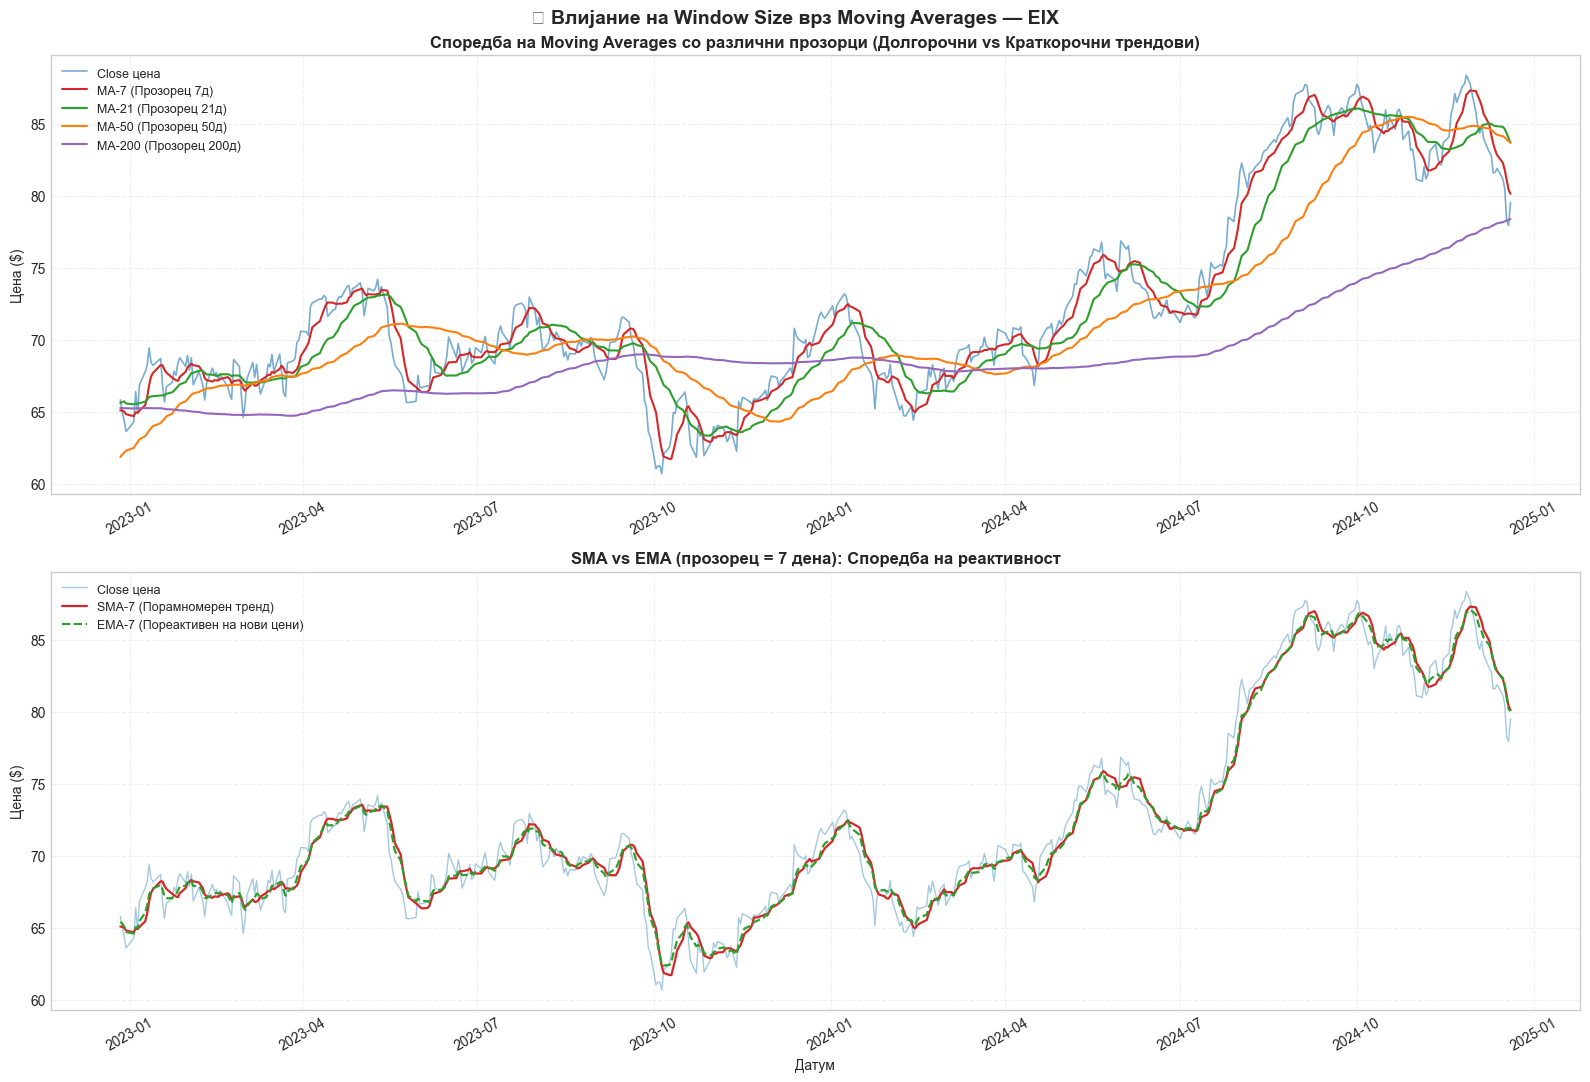

In [164]:


fig, axes = plt.subplots(2, 1, figsize=(16, 11))
fig.suptitle(f'📉 Влијание на Window Size врз Moving Averages — {TICKER}', fontsize=14, fontweight='bold', y=0.98)


axes[0].plot(sample['Date'], sample['Close'], color='#1f77b4', linewidth=1.2, alpha=0.6, label='Close цена')
colors_ma = {7: '#d62728', 21: '#2ca02c', 50: '#ff7f0e', 200: '#9467bd'}

for w in ma_windows:
    axes[0].plot(sample['Date'], sample[f'MA_{w}'], linewidth=1.5, label=f'MA-{w} (Прозорец {w}д)', color=colors_ma[w])

axes[0].set_title('Споредба на Moving Averages со различни прозорци (Долгорочни vs Краткорочни трендови)', fontweight='bold')
axes[0].set_ylabel('Цена ($)')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=30)  
axes[0].grid(True, linestyle='--', alpha=0.3)


axes[1].plot(sample['Date'], sample['Close'], color='#1f77b4', linewidth=1, alpha=0.4, label='Close цена')
axes[1].plot(sample['Date'], sample['SMA_7'], linewidth=1.6, color='#d62728', label='SMA-7 (Порамномерен тренд)')
axes[1].plot(sample['Date'], sample['EMA_7'], linewidth=1.6, color='#2ca02c', linestyle='--', label='EMA-7 (Пореактивен на нови цени)')

axes[1].set_title('SMA vs EMA (прозорец = 7 дена): Споредба на реактивност', fontweight='bold')
axes[1].set_xlabel('Датум')
axes[1].set_ylabel('Цена ($)')
axes[1].legend(fontsize=9, loc='upper left')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=30)  
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 6. Корелациска Анализа

Пресметка на Корелациска Матрица

In [165]:

feature_cols = ['MA_Trend_Diff', 'EMA_Spread', 'BB_Width', 'Momentum_5',
                'Momentum_10', 'Volatility_7', 'RSI', 'Close_Lag1', 'Close_Lag2',
                'Target_Price']


corr = df_ml[feature_cols].corr()
print(corr)

print(" Чекор 1: Корелациската матрица за избраните карактеристики е успешно пресметана.")

               MA_Trend_Diff  EMA_Spread  BB_Width  Momentum_5  Momentum_10  \
MA_Trend_Diff       1.000000    0.821347 -0.351612    0.522941     0.854316   
EMA_Spread          0.821347    1.000000 -0.485266    0.329229     0.610765   
BB_Width           -0.351612   -0.485266  1.000000   -0.089714    -0.227098   
Momentum_5          0.522941    0.329229 -0.089714    1.000000     0.705885   
Momentum_10         0.854316    0.610765 -0.227098    0.705885     1.000000   
Volatility_7       -0.380721   -0.382773  0.597026   -0.344168    -0.370101   
RSI                 0.805078    0.664631 -0.081210    0.537896     0.744087   
Close_Lag1          0.273573    0.428601 -0.330637    0.153549     0.219536   
Close_Lag2          0.263313    0.421199 -0.329638    0.096325     0.177223   
Target_Price        0.273743    0.426062 -0.328403    0.152385     0.218310   

               Volatility_7       RSI  Close_Lag1  Close_Lag2  Target_Price  
MA_Trend_Diff     -0.380721  0.805078    0.273573   

Визуелизација на Корелација и Влијание врз Target

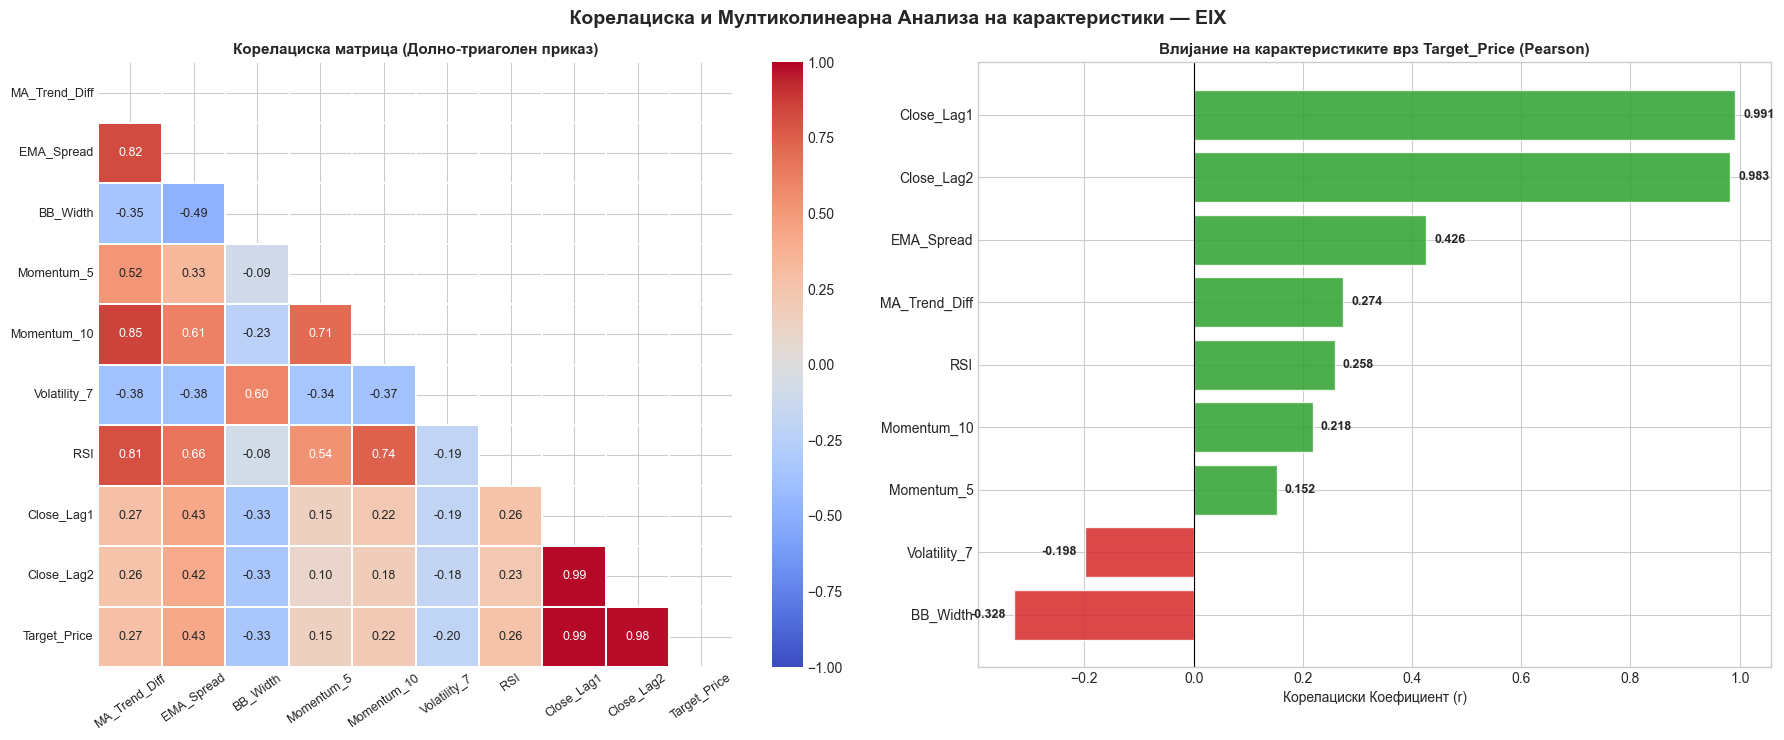

In [166]:


fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
fig.suptitle(f' Корелациска и Мултиколинеарна Анализа на карактеристики — {TICKER}', fontsize=14, fontweight='bold', y=0.98)


mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.3, ax=axes[0], mask=mask, annot_kws={"size": 9})

axes[0].set_title('Корелациска матрица (Долно-триаголен приказ)', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=35, labelsize=9)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)


target_corr = corr['Target_Price'].drop('Target_Price').sort_values(ascending=True)
colors = ['#d62728' if v < 0 else '#2ca02c' for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='-')
axes[1].set_title('Влијание на карактеристиките врз Target_Price (Pearson)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Корелациски Коефициент (r)')

for i, v in enumerate(target_corr.values):
    offset = 0.015 if v >= 0 else -0.015
    align = 'left' if v >= 0 else 'right'
    axes[1].text(v + offset, i, f'{v:.3f}', va='center', ha=align, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

Автоматска Детекција на Мултиколинеарност (|r| > 0.90)

In [167]:


print("=" * 65)
print("  ДЕТЕКЦИЈА НА ВИСОКА МУЛТИКОЛИНЕАРНОСТ (|r| > 0.90):")
print("=" * 65)

high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
       
        if corr.columns[i] != 'Target_Price' and corr.columns[j] != 'Target_Price':
            if abs(corr.iloc[i,j]) > 0.90:
                high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i,j]))

if high_corr:
    for a, b, r in high_corr:
        print(f"  Висок ризик: {a} ↔ {b} | r = {r:.4f}")
else:
    print("  Одлично! Нема пронајдено критична мултиколинеарност меѓу влезните карактеристики.")
print("=" * 65)

  ДЕТЕКЦИЈА НА ВИСОКА МУЛТИКОЛИНЕАРНОСТ (|r| > 0.90):
  Висок ризик: Close_Lag1 ↔ Close_Lag2 | r = 0.9914


Чистење на мултиколинеарната карактеристика

In [168]:

FEATURE_COLS_TO_DROP = sorted({b for (a, b, r) in high_corr})

if FEATURE_COLS_TO_DROP:
    df_ml.drop(columns=FEATURE_COLS_TO_DROP, inplace=True, errors='ignore')
    print(f" Успешно исфрлени колоните {FEATURE_COLS_TO_DROP} за да се елиминира мултиколинеарноста.")
else:
    print(" ✅ Нема детектирана мултиколинеарност во избраните карактеристики — ништо не се отфрла.")

print(f"Нови димензии на датасетот: {df_ml.shape[0]} денови x {df_ml.shape[1]} колони")

 Успешно исфрлени колоните ['Close_Lag2'] за да се елиминира мултиколинеарноста.
Нови димензии на датасетот: 2497 денови x 26 колони


## 7. Train/Test Split — Хронолошки

Кај временски серии е **забрането** да се користи рандом сплит.  
Секогаш тренираме на минатото и тестираме на иднината (80/20).


Хронолошки сплит (Спречување на Look-Ahead Bias)

In [169]:

FEATURE_COLS = ['Close_Lag1', 'Momentum_5', 'Momentum_10', 'MA_Trend_Diff',
                'EMA_Spread', 'BB_Width', 'Volatility_7', 'RSI']


FEATURE_COLS = [c for c in FEATURE_COLS if c not in globals().get('FEATURE_COLS_TO_DROP', [])]

X = df_ml[FEATURE_COLS]
y = df_ml['Target_Price']


split_idx = int(len(df_ml) * 0.80)

X_train_raw = X.iloc[:split_idx]
X_test_raw  = X.iloc[split_idx:]
y_train     = y.iloc[:split_idx]
y_test      = y.iloc[split_idx:]

print(f" Хронолошки сплит: 80% тренирање / 20% тестирање")
print(f"   Тренинг период:  {df_ml['Date'].iloc[0].date()} → {df_ml['Date'].iloc[split_idx-1].date()} ({len(y_train)} денови)")
print(f"   Тест период:     {df_ml['Date'].iloc[split_idx].date()} → {df_ml['Date'].iloc[-1].date()} ({len(y_test)} денови)")
print(f"   Карактеристики:  {FEATURE_COLS}")

 Хронолошки сплит: 80% тренирање / 20% тестирање
   Тренинг период:  2015-01-22 → 2022-12-23 (1997 денови)
   Тест период:     2022-12-27 → 2024-12-20 (500 денови)
   Карактеристики:  ['Close_Lag1', 'Momentum_5', 'Momentum_10', 'MA_Trend_Diff', 'EMA_Spread', 'BB_Width', 'Volatility_7', 'RSI']


Визуелен приказ на поделбата

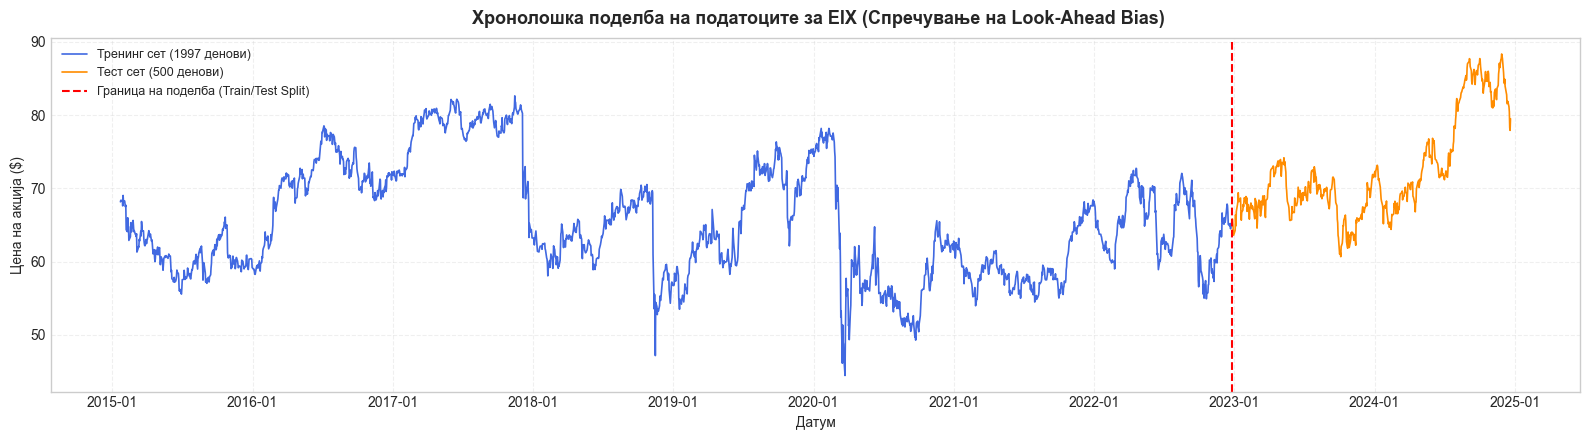

In [170]:


fig, ax = plt.subplots(figsize=(16, 4.5))
ax.plot(df_ml['Date'].iloc[:split_idx], y_train, label=f'Тренинг сет ({len(y_train)} денови)', color='royalblue', linewidth=1.2)
ax.plot(df_ml['Date'].iloc[split_idx:], y_test,  label=f'Тест сет ({len(y_test)} денови)',     color='darkorange', linewidth=1.2)
ax.axvline(df_ml['Date'].iloc[split_idx], color='red', linestyle='--', linewidth=1.5, label='Граница на поделба (Train/Test Split)')

ax.set_title(f' Хронолошка поделба на податоците за {TICKER} (Спречување на Look-Ahead Bias)', fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Цена на акција ($)')
ax.set_xlabel('Датум')
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Зачувување на базни цени и Скалирање (StandardScaler)

In [171]:

y_test_current_prices = X_test_raw['Close_Lag1'].copy()


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw) 

print(" StandardScaler успешно применет.")
print("   • Моделот ќе учи од карактеристики каде просекот е 0 и варијансата е 1.")
print("   • Матрицата за тренирање е безбедна од Data Leakage (фитот е направен исклучиво на минатото).")

 StandardScaler успешно применет.
   • Моделот ќе учи од карактеристики каде просекот е 0 и варијансата е 1.
   • Матрицата за тренирање е безбедна од Data Leakage (фитот е направен исклучиво на минатото).


##  8. Тренирање на ML Модели

Тренираме 4 класични ML модели и ги споредуваме со Наивна Базна линија.




Дефинирање на ML моделите со регуларизација

In [172]:

print(" Подготовка на пазарните ML модели со заштита од overfitting...")


all_models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=3, random_state=42),
    "KNN":           KNeighborsRegressor(n_neighbors=7, weights='distance'),
    "SVR":           SVR(kernel='rbf', C=10.0, epsilon=0.05, gamma='scale'),
    "XGBoost":       XGBRegressor(n_estimators=200, learning_rate=0.03, max_depth=5,
                                  subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
}

train_times = {}
print(" Моделите се успешно конфигурирани во меморијата!")

 Подготовка на пазарните ML модели со заштита од overfitting...
 Моделите се успешно конфигурирани во меморијата!


Поставување на Naive Baseline (Базна линија)

In [173]:
train_times["Naive Baseline"] = 0.00
print(f"    [{train_times['Naive Baseline']:5.2f}s] Naive Baseline — поставена како базна линија")

    [ 0.00s] Naive Baseline — поставена како базна линија


Тренирање (Обука) на сите ML модели

In [174]:
print(" Тренирање на пазарните ML модели врз скалираните податоци...")

for name, model in all_models.items():
    t0 = time.time()
    model.fit(X_train_scaled, y_train) 
    train_times[name] = round(time.time() - t0, 2)
    print(f"    [{train_times[name]:5.2f}s] {name} — тренирање успешно завршено")

print("\n Сите пазарни модели се успешно истренирани и подготвени за евалуација.")

 Тренирање на пазарните ML модели врз скалираните податоци...
    [ 3.33s] Random Forest — тренирање успешно завршено
    [ 0.01s] KNN — тренирање успешно завршено
    [ 0.46s] SVR — тренирање успешно завршено
    [ 0.38s] XGBoost — тренирање успешно завршено

 Сите пазарни модели се успешно истренирани и подготвени за евалуација.


## Cross-Validation (TimeSeriesSplit)

Провера на стабилноста на моделите низ 5 хронолошки фолди. Ова дава поверодостојна слика за тоа колку добро секој модел генерализира на невидени временски периоди.

   CROSS-VALIDATION (TimeSeriesSplit, 5 фолди)
   Секој фолд: тренира на минато → тестира на иднина


  Random Forest         CV MAE: $1.19 ± 0.34
  KNN                   CV MAE: $2.46 ± 0.51
  SVR                   CV MAE: $1.61 ± 0.44
  XGBoost               CV MAE: $1.75 ± 0.79

   РЕЗУЛТАТИ ОД CROSS-VALIDATION


,CV MAE mean ($),CV MAE std ($),CV RMSE mean ($),CV R² mean (%),Train R² mean (%),CV Overfit Gap
Random Forest,1.19,0.34,1.68,92.67,99.20,6.53
SVR,1.61,0.44,2.51,82.67,98.75,16.08
XGBoost,1.75,0.79,2.36,85.27,99.33,14.06
KNN,2.46,0.51,3.26,71.47,100.00,28.53


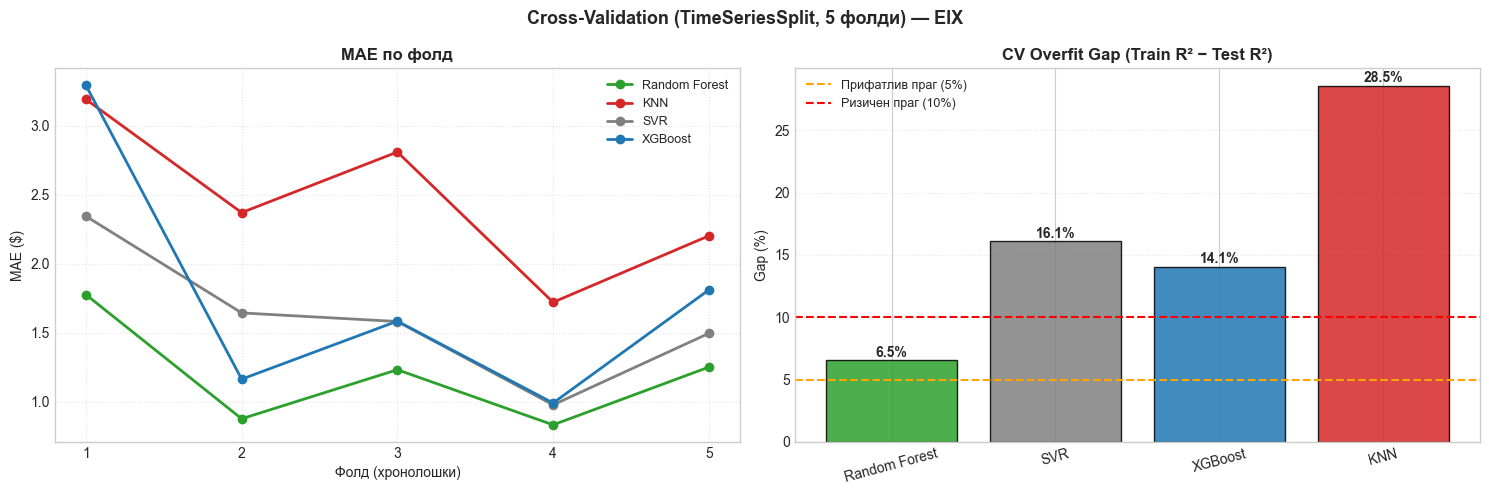


 ТОЛКУВАЊЕ:
   • CV MAE std мал  → моделот е стабилен низ различни периоди
   • CV Overfit Gap < 5%  → добро генерализира
   • CV Overfit Gap 5-10% → умерен overfitting, прифатливо
   • CV Overfit Gap > 10% → значаен overfitting, внимавај


In [175]:

print("=" * 65)
print("   CROSS-VALIDATION (TimeSeriesSplit, 5 фолди)")
print("   Секој фолд: тренира на минато → тестира на иднина")
print("=" * 65)

N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

X_all_raw = pd.concat([X_train_raw, X_test_raw], axis=0).reset_index(drop=True)
y_all     = pd.concat([y_train,     y_test],     axis=0).reset_index(drop=True)

cv_results = {}

for name, model in all_models.items():
    
    pipe = Pipeline([
        ('scaler', SS()),
        ('model',  model.__class__(**model.get_params()))
    ])
    
    cv = cross_validate(
        pipe, X_all_raw, y_all,
        cv=tscv,
        scoring={
            'mae':  'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error',
            'r2':   'r2',
        },
        return_train_score=True,
        n_jobs=-1
    )
    
    cv_results[name] = {
        'CV MAE mean ($)':   round(-cv['test_mae'].mean(), 2),
        'CV MAE std  ($)':   round( cv['test_mae'].std(),  2),
        'CV RMSE mean ($)':  round(-cv['test_rmse'].mean(),2),
        'CV R² mean (%)':    round( cv['test_r2'].mean() * 100, 2),
        'Train R² mean (%)': round( cv['train_r2'].mean()* 100, 2),
        'CV Overfit Gap':    round((cv['train_r2'].mean() - cv['test_r2'].mean()) * 100, 2),
    }
    print(f"  {name:<20}  CV MAE: ${-cv['test_mae'].mean():.2f} ± {cv['test_mae'].std():.2f}")

df_cv = pd.DataFrame(cv_results).T.sort_values('CV MAE mean ($)')

print("\n" + "=" * 65)
print("   РЕЗУЛТАТИ ОД CROSS-VALIDATION")
print("=" * 65)
display(df_cv)
print("=" * 65)




fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'Cross-Validation (TimeSeriesSplit, {N_SPLITS} фолди) — {TICKER}',
             fontsize=13, fontweight='bold')

colors_map = {
    'Random Forest': '#2ca02c',
    'XGBoost':       '#1f77b4',
    'SVM':           '#ff7f0e',
    'KNN':           '#d62728',
}


ax = axes[0]
for name, model in all_models.items():
    pipe = Pipeline([('scaler', SS()), ('model', model.__class__(**model.get_params()))])
    fold_maes = []
    for fold_idx, (tr_idx, te_idx) in enumerate(tscv.split(X_all_raw)):
        pipe.fit(X_all_raw.iloc[tr_idx], y_all.iloc[tr_idx])
        preds = pipe.predict(X_all_raw.iloc[te_idx])
        from sklearn.metrics import mean_absolute_error as _mae
        fold_maes.append(_mae(y_all.iloc[te_idx], preds))
    ax.plot(range(1, N_SPLITS+1), fold_maes, marker='o', linewidth=2,
            label=name, color=colors_map.get(name, 'gray'))

ax.set_title('MAE по фолд', fontweight='bold')
ax.set_xlabel('Фолд (хронолошки)')
ax.set_ylabel('MAE ($)')
ax.legend(fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xticks(range(1, N_SPLITS+1))


ax2 = axes[1]
names = list(df_cv.index)
gaps  = df_cv['CV Overfit Gap'].values
bar_colors = [colors_map.get(n, 'gray') for n in names]
bars = ax2.bar(names, gaps, color=bar_colors, edgecolor='black', alpha=0.85)
ax2.axhline(5, color='orange', linestyle='--', linewidth=1.5, label='Прифатлив праг (5%)')
ax2.axhline(10, color='red',   linestyle='--', linewidth=1.5, label='Ризичен праг (10%)')
ax2.set_title('CV Overfit Gap (Train R² − Test R²)', fontweight='bold')
ax2.set_ylabel('Gap (%)')
ax2.legend(fontsize=9)
ax2.tick_params(axis='x', rotation=15)
ax2.grid(True, linestyle=':', alpha=0.5, axis='y')
for bar, v in zip(bars, gaps):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n ТОЛКУВАЊЕ:")
print("   • CV MAE std мал  → моделот е стабилен низ различни периоди")
print("   • CV Overfit Gap < 5%  → добро генерализира")
print("   • CV Overfit Gap 5-10% → умерен overfitting, прифатливо")
print("   • CV Overfit Gap > 10% → значаен overfitting, внимавај")


### 8.1 Евалуација и споредба на ML модели

Дефинирање на Функцијата за Евалуација

In [176]:


def evaluate_model(name, model, X_t, y_t, y_tr, X_tr):
   
    preds = model.predict(X_t)
    preds_train = model.predict(X_tr)
    
    
    mae   = mean_absolute_error(y_t, preds)
    rmse  = np.sqrt(mean_squared_error(y_t, preds))
    r2    = r2_score(y_t, preds)
    mape  = np.mean(np.abs((y_t - preds) / (y_t + 1e-9))) * 100
    r2_tr = r2_score(y_tr, preds_train)
    
    return {
        "MAE ($)": round(mae, 2),
        "RMSE ($)": round(rmse, 2),
        "R² Test (%)": round(r2 * 100, 2),
        "R² Train (%)": round(r2_tr * 100, 2),
        "MAPE (%)": round(mape, 2),
        "Overfit Gap": round((r2_tr - r2) * 100, 2)
    }

print(" Функцијата `evaluate_model` е подготвена за работа.")

 Функцијата `evaluate_model` е подготвена за работа.


Евалуација и Печатење на Споредбената Табела

In [177]:

naive_mae  = mean_absolute_error(y_test, y_test_current_prices)
naive_rmse = np.sqrt(mean_squared_error(y_test, y_test_current_prices))
naive_r2   = r2_score(y_test, y_test_current_prices)
naive_mape = np.mean(np.abs((y_test - y_test_current_prices) / (y_test + 1e-9))) * 100

comparison_results = {}


for name, model in all_models.items():
    comparison_results[name] = evaluate_model(name, model, X_test_scaled, y_test, y_train, X_train_scaled)


comparison_results["Naive Baseline"] = {
    "MAE ($)": round(naive_mae, 2), 
    "RMSE ($)": round(naive_rmse, 2),
    "R² Test (%)": round(naive_r2 * 100, 2), 
    "R² Train (%)": "-",
    "MAPE (%)": round(naive_mape, 2), 
    "Overfit Gap": "-"
}


df_comparison = pd.DataFrame(comparison_results).T

print("\n" + "=" * 65)
print("         ФИНАЛЕН ИЗВЕШТАЈ: СПОРЕДБА НА СИТЕ ML МОДЕЛИ")
print("=" * 65)
display(df_comparison.sort_values(by="MAE ($)"))
print("=" * 65)



         ФИНАЛЕН ИЗВЕШТАЈ: СПОРЕДБА НА СИТЕ ML МОДЕЛИ


,MAE ($),RMSE ($),R² Test (%),R² Train (%),MAPE (%),Overfit Gap
Naive Baseline,0.71,0.9,98.25,-,0.99,-
Random Forest,1.18,1.75,93.31,98.95,1.56,5.64
SVR,1.39,2.05,90.83,98.56,1.81,7.72
XGBoost,1.69,2.5,86.38,98.95,2.18,12.57
KNN,2.09,2.86,82.19,100.0,2.74,17.81


Детекција на победник и подготовка на податоци за цртање

In [178]:

baseline_key = "Naive Baseline" if "Naive Baseline" in df_comparison.index else "Naïve Baseline"
best_ml_name = df_comparison.drop(baseline_key)["MAE ($)"].idxmin()


best_ml      = all_models[best_ml_name]
best_preds   = best_ml.predict(X_test_scaled)
test_dates   = df_ml['Date'].iloc[split_idx:]

print(f" Автоматски детектиран победник меѓу класичните ML алгоритми: {best_ml_name}")
print(" Податоците за визуелизација на тест периодот се успешно подготвени.")

 Автоматски детектиран победник меѓу класичните ML алгоритми: Random Forest
 Податоците за визуелизација на тест периодот се успешно подготвени.


Цртање на Компаративната Мрежа од Графикони

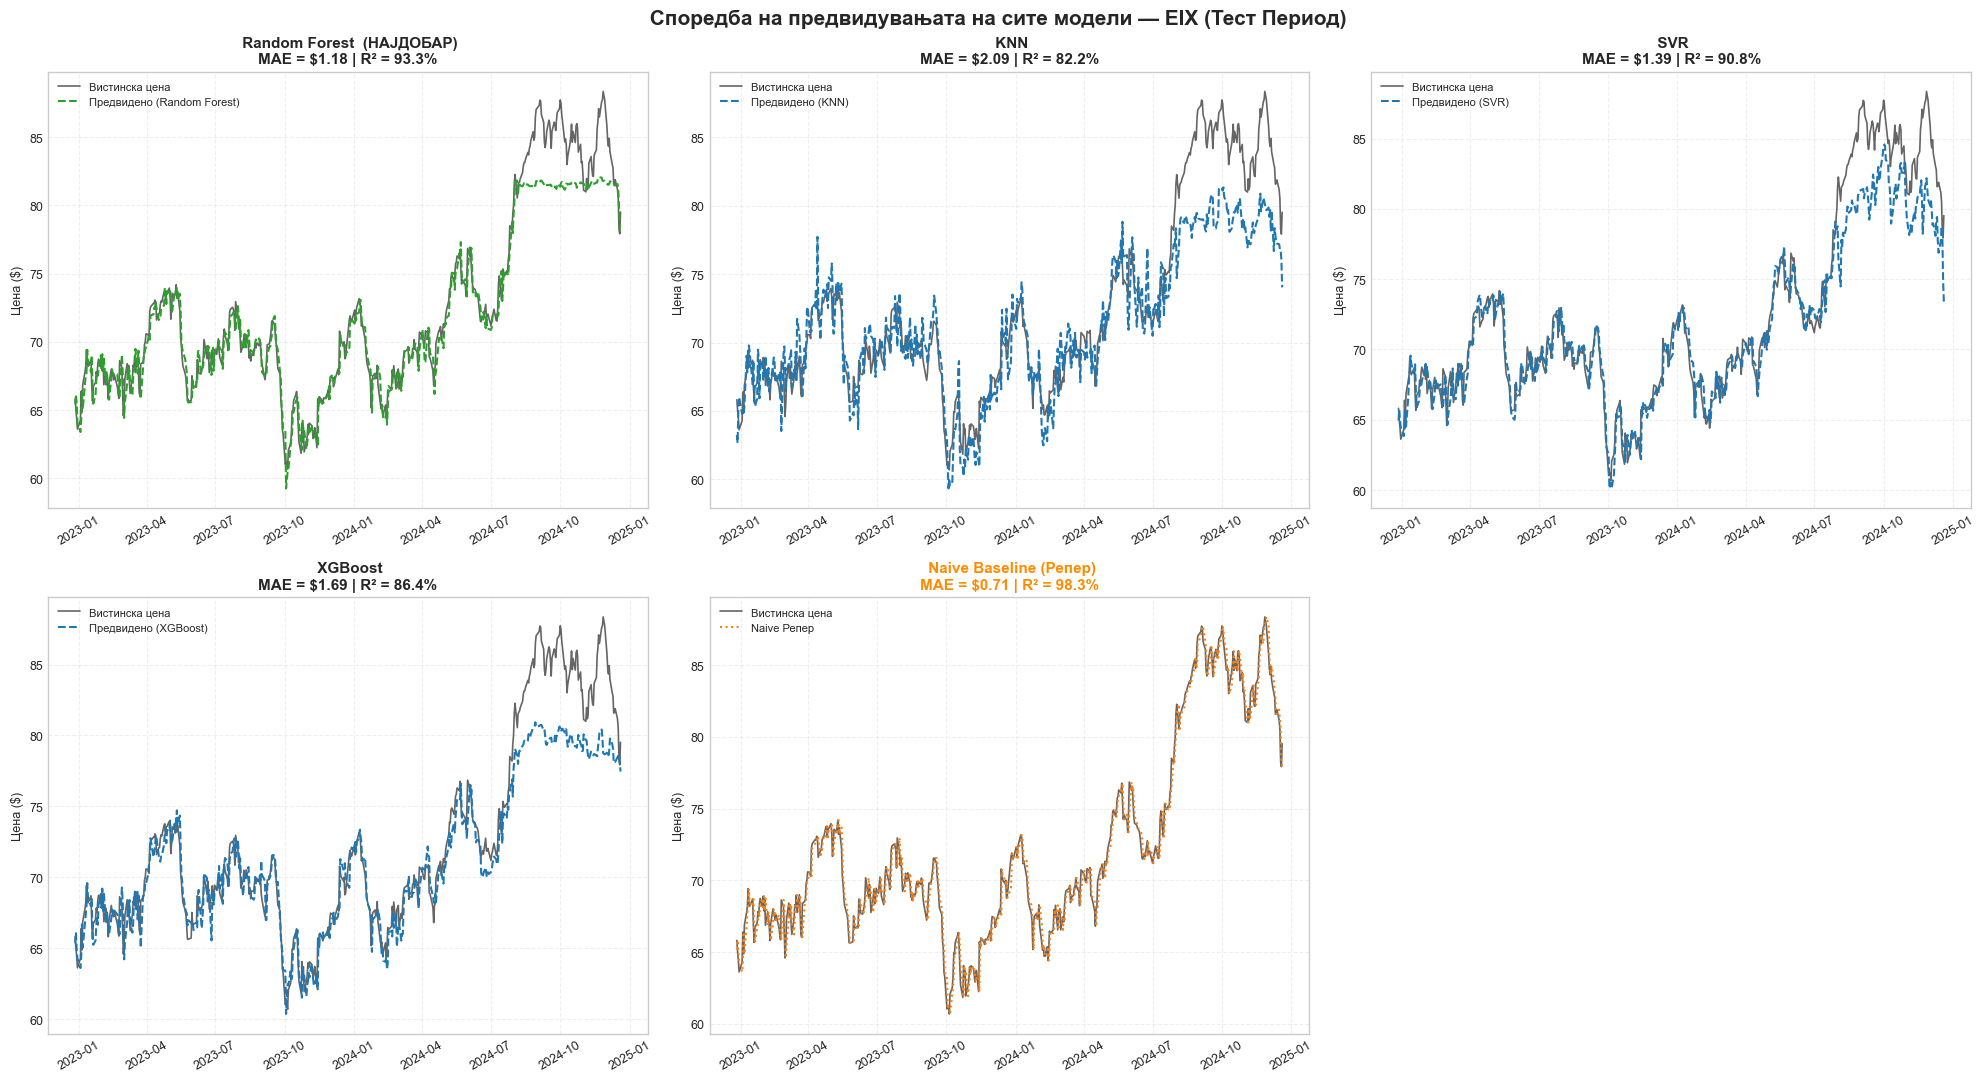

In [179]:

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle(f' Споредба на предвидувањата на сите модели — {TICKER} (Тест Период)', fontsize=15, fontweight='bold', y=0.98)


plot_dict = all_models.copy()
plot_dict["Naive Baseline"] = "baseline_marker"

for ax, name in zip(axes.flat, plot_dict.keys()):
    
    if name == "Naive Baseline":
       
        preds = y_test_current_prices.values
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
    else:
       
        preds = plot_dict[name].predict(X_test_scaled)
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        
   
    ax.plot(test_dates, y_test.values, color='black', linewidth=1.2, alpha=0.6, label='Вистинска цена')
    
    if name == "Naive Baseline":
        ax.plot(test_dates, preds, color='#ff7f0e', linestyle=':', linewidth=1.5, label='Naive Репер')
        ax.set_title(f' {name} (Репер)\nMAE = ${mae:.2f} | R² = {r2*100:.1f}%', fontsize=11, fontweight='bold', color='darkorange')
    else:
        
        is_best = (name == best_ml_name)
        line_color = '#2ca02c' if is_best else '#1f77b4'
        title_extra = "  (НАЈДОБАР)" if is_best else ""
        
        ax.plot(test_dates, preds, color=line_color, linestyle='--', linewidth=1.5, label=f'Предвидено ({name})')
        ax.set_title(f' {name}{title_extra}\nMAE = ${mae:.2f} | R² = {r2*100:.1f}%', fontsize=11, fontweight='bold')

    ax.set_ylabel('Цена ($)', fontsize=9)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    
    
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)


fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()



## 📉 9. Анализа на Временска Серија — ARIMA




Дефинирање на ADF Тестот за Стационарност

In [180]:
arima_train = df_ml['Close'].iloc[:split_idx]
arima_test  = df_ml['Close'].iloc[split_idx:]


def arima_walk_forward_evaluation(train_series, test_series, order=(1,1,1)):
    history = list(train_series.values)
    predictions = []

    print("Започнува вистинска ARIMA Walk-Forward прогноза на тест сетот...")
    start_time = time.time()

    for t in range(len(test_series)):
        model = ARIMA(history, order=order)
        model_fit = model.fit()

      
        yhat = model_fit.forecast(steps=1)[0]
        predictions.append(yhat)

        
        history.append(test_series.iloc[t])

        if (t + 1) % 20 == 0 or (t + 1) == len(test_series):
            print(f"   Прогрес: евалуирани {t + 1}/{len(test_series)} денови...")

    print(f"Завршено за {time.time() - start_time:.2f} секунди.")
    return pd.Series(predictions, index=test_series.index)

ARIMA_ORDER = (1, 1, 1)
arima_preds = arima_walk_forward_evaluation(arima_train, arima_test, order=ARIMA_ORDER)

Започнува вистинска ARIMA Walk-Forward прогноза на тест сетот...
   Прогрес: евалуирани 20/500 денови...
   Прогрес: евалуирани 40/500 денови...
   Прогрес: евалуирани 60/500 денови...
   Прогрес: евалуирани 80/500 денови...
   Прогрес: евалуирани 100/500 денови...
   Прогрес: евалуирани 120/500 денови...
   Прогрес: евалуирани 140/500 денови...
   Прогрес: евалуирани 160/500 денови...
   Прогрес: евалуирани 180/500 денови...
   Прогрес: евалуирани 200/500 денови...
   Прогрес: евалуирани 220/500 денови...
   Прогрес: евалуирани 240/500 денови...
   Прогрес: евалуирани 260/500 денови...
   Прогрес: евалуирани 280/500 денови...
   Прогрес: евалуирани 300/500 денови...
   Прогрес: евалуирани 320/500 денови...
   Прогрес: евалуирани 340/500 денови...
   Прогрес: евалуирани 360/500 денови...
   Прогрес: евалуирани 380/500 денови...
   Прогрес: евалуирани 400/500 денови...
   Прогрес: евалуирани 420/500 денови...
   Прогрес: евалуирани 440/500 денови...
   Прогрес: евалуирани 460/500 денови

In [181]:

arima_mae   = mean_absolute_error(arima_test, arima_preds)
arima_rmse  = np.sqrt(mean_squared_error(arima_test, arima_preds))
arima_r2    = r2_score(arima_test, arima_preds)
arima_mape  = np.mean(np.abs((arima_test - arima_preds) / (arima_test + 1e-9))) * 100

ARIMA_LABEL = f"ARIMA{ARIMA_ORDER}"

print(f"\n{'='*55}")
print(f"     ЕКОНОМЕТРИСКИ РЕЗУЛТАТИ: {ARIMA_LABEL}")
print(f"{'='*55}")
print(f"   MAE  ($):   {arima_mae:.2f}")
print(f"   RMSE ($):   {arima_rmse:.2f}")
print(f"   R2   (%):   {arima_r2*100:.2f}%")
print(f"   MAPE (%):   {arima_mape:.2f}%")
print(f"{'='*55}")


df_comparison.loc[ARIMA_LABEL] = {
    "MAE ($)": round(arima_mae, 2),
    "RMSE ($)": round(arima_rmse, 2),
    "R² Test (%)": round(arima_r2 * 100, 2),
    "R² Train (%)": "-",
    "MAPE (%)": round(arima_mape, 2),
    "Overfit Gap": "-"
}
print(f" {ARIMA_LABEL} резултатите се успешно додадени во финалната компаративна табела!")



     ЕКОНОМЕТРИСКИ РЕЗУЛТАТИ: ARIMA(1, 1, 1)
   MAE  ($):   0.71
   RMSE ($):   0.90
   R2   (%):   98.25%
   MAPE (%):   0.99%
 ARIMA(1, 1, 1) резултатите се успешно додадени во финалната компаративна табела!


## 🧠 10. Длабоко Учење — LSTM (Long Short-Term Memory)

LSTM е специјален тип на рекурентна невронска мрежа (RNN) дизајниран 
за **временски серии со долгорочни зависности**.

Ги памети важните информации преку **Gates** (Input, Forget, Output).


Изолирање на цените и Скалирање со MinMaxScaler

In [182]:

LSTM_LOOKBACK = 20  


train_close = df_ml['Close'].iloc[:split_idx].values.reshape(-1, 1)
test_close  = df_ml['Close'].iloc[split_idx:].values.reshape(-1, 1)


test_lookback_inputs = df_ml['Close'].iloc[split_idx - LSTM_LOOKBACK:].values.reshape(-1, 1)


lstm_scaler  = MinMaxScaler(feature_range=(0, 1))
train_scaled = lstm_scaler.fit_transform(train_close)
test_scaled  = lstm_scaler.transform(test_lookback_inputs) 

print(" Чекор 1: Цените се успешно скалирани во опсег од 0 до 1.")

 Чекор 1: Цените се успешно скалирани во опсег од 0 до 1.


Функција за Лизгачки прозорци (Sliding Windows)

In [183]:

def create_lstm_sequences(data, lookback):
    X_seq, y_seq = [], []
    for i in range(lookback, len(data)):
        
        X_seq.append(data[i - lookback:i, 0])
       
        y_seq.append(data[i, 0])
    return np.array(X_seq), np.array(y_seq)

print(" Чекор 2: Функцијата `create_lstm_sequences` е подготвена за работа.")

 Чекор 2: Функцијата `create_lstm_sequences` е подготвена за работа.


Креирање на 3D секвенци за Keras

In [184]:

X_lstm_train, y_lstm_train = create_lstm_sequences(train_scaled, LSTM_LOOKBACK)
X_lstm_test, y_lstm_test   = create_lstm_sequences(test_scaled, LSTM_LOOKBACK)


X_lstm_train = X_lstm_train.reshape(X_lstm_train.shape[0], X_lstm_train.shape[1], 1)
X_lstm_test  = X_lstm_test.reshape(X_lstm_test.shape[0], X_lstm_test.shape[1], 1)

print(f" LSTM Подготовка успешно завршена:")
print(f"   • Искористен пазарен прозорец (Lookback): {LSTM_LOOKBACK} денови")
print(f"   • Влез во тренинг сет (X_train Shape):    {X_lstm_train.shape}  -> [Samples, Timesteps, Features]")
print(f"   • Влез во тест сет (X_test Shape):       {X_lstm_test.shape}")
print(f"   • Вкупен број на тренинг секвенци:        {len(X_lstm_train)}")
print(f"   • Вкупен број на тест секвенци:           {len(X_lstm_test)}")

 LSTM Подготовка успешно завршена:
   • Искористен пазарен прозорец (Lookback): 20 денови
   • Влез во тренинг сет (X_train Shape):    (1977, 20, 1)  -> [Samples, Timesteps, Features]
   • Влез во тест сет (X_test Shape):       (500, 20, 1)
   • Вкупен број на тренинг секвенци:        1977
   • Вкупен број на тест секвенци:           500


Дефинирање на Архитектурата на LSTM

In [185]:
tf.random.set_seed(42)


lstm_model = Sequential([
    Input(shape=(LSTM_LOOKBACK, 1)), 
    
    LSTM(64, return_sequences=True),
    Dropout(0.2),                    
    
    LSTM(32, return_sequences=False),
    Dropout(0.2),                    
    
    Dense(16, activation='relu'),    
    Dense(1)                        
])


lstm_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])


lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 20, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Тренирање на мрежата со Early Stopping

In [186]:

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

print(" Тренирање на пазарната LSTM невронска мрежа (ова може да потрае неколку секунди)...")
history_lstm = lstm_model.fit(
    X_lstm_train, y_lstm_train,
    epochs=80,                
    batch_size=32,            
    validation_split=0.10,    
    callbacks=[early_stop],   
    verbose=0                 
)

total_epochs = len(history_lstm.history['loss'])
print(f" LSTM тренирање успешно завршено. Вкупно извршени епохи пред стопирање: {total_epochs}")

 Тренирање на пазарната LSTM невронска мрежа (ова може да потрае неколку секунди)...
Restoring model weights from the end of the best epoch: 80.
 LSTM тренирање успешно завршено. Вкупно извршени епохи пред стопирање: 80


Визуелизација на Кривата на Учење (Learning Curves)

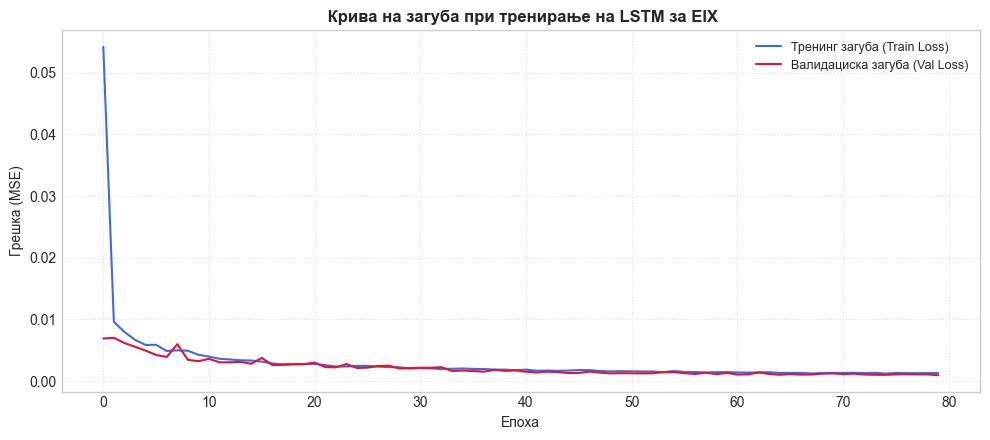

In [187]:
plt.figure(figsize=(10, 4.5))
plt.plot(history_lstm.history['loss'], label='Тренинг загуба (Train Loss)', color='royalblue', linewidth=1.5)
plt.plot(history_lstm.history['val_loss'], label='Валидациска загуба (Val Loss)', color='crimson', linewidth=1.5)
plt.title(f' Крива на загуба при тренирање на LSTM за {TICKER}', fontsize=12, fontweight='bold')
plt.xlabel('Епоха')
plt.ylabel('Грешка (MSE)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()



Евалуација на LSTM и пресметка на финални метрики

In [188]:

lstm_preds_scaled = lstm_model.predict(X_lstm_test, verbose=0)


lstm_preds = lstm_scaler.inverse_transform(lstm_preds_scaled).flatten()
y_lstm_actual = lstm_scaler.inverse_transform(y_lstm_test.reshape(-1, 1)).flatten()


lstm_mae  = mean_absolute_error(y_lstm_actual, lstm_preds)
lstm_rmse = np.sqrt(mean_squared_error(y_lstm_actual, lstm_preds))
lstm_r2   = r2_score(y_lstm_actual, lstm_preds)
lstm_mape = np.mean(np.abs((y_lstm_actual - lstm_preds) / (y_lstm_actual + 1e-9))) * 100

print(f"{'='*55}")
print(f"   ДЛАБОКО УЧЕЊЕ: LSTM НЕВРОНСКА МРЕЖА — РЕЗУЛТАТИ")
print(f"{'='*55}")
print(f"   MAE  ($):   {lstm_mae:.2f}")
print(f"   RMSE ($):   {lstm_rmse:.2f}")
print(f"   R²   (%):   {lstm_r2*100:.2f}%")
print(f"   MAPE (%):   {lstm_mape:.2f}%")
print(f"{'='*55}")


df_comparison.loc["LSTM"] = {
    "MAE ($)": round(lstm_mae, 2), 
    "RMSE ($)": round(lstm_rmse, 2),
    "R² Test (%)": round(lstm_r2 * 100, 2), 
    "R² Train (%)": "-",  
    "MAPE (%)": round(lstm_mape, 2), 
    "Overfit Gap": "-"
}
print(" LSTM резултатите се зачувани во финалната матрица за евалуација.")

   ДЛАБОКО УЧЕЊЕ: LSTM НЕВРОНСКА МРЕЖА — РЕЗУЛТАТИ
   MAE  ($):   1.13
   RMSE ($):   1.45
   R²   (%):   95.40%
   MAPE (%):   1.50%
 LSTM резултатите се зачувани во финалната матрица за евалуација.


Визуелизација (Глобален преглед vs Микро Зум од 60 дена)

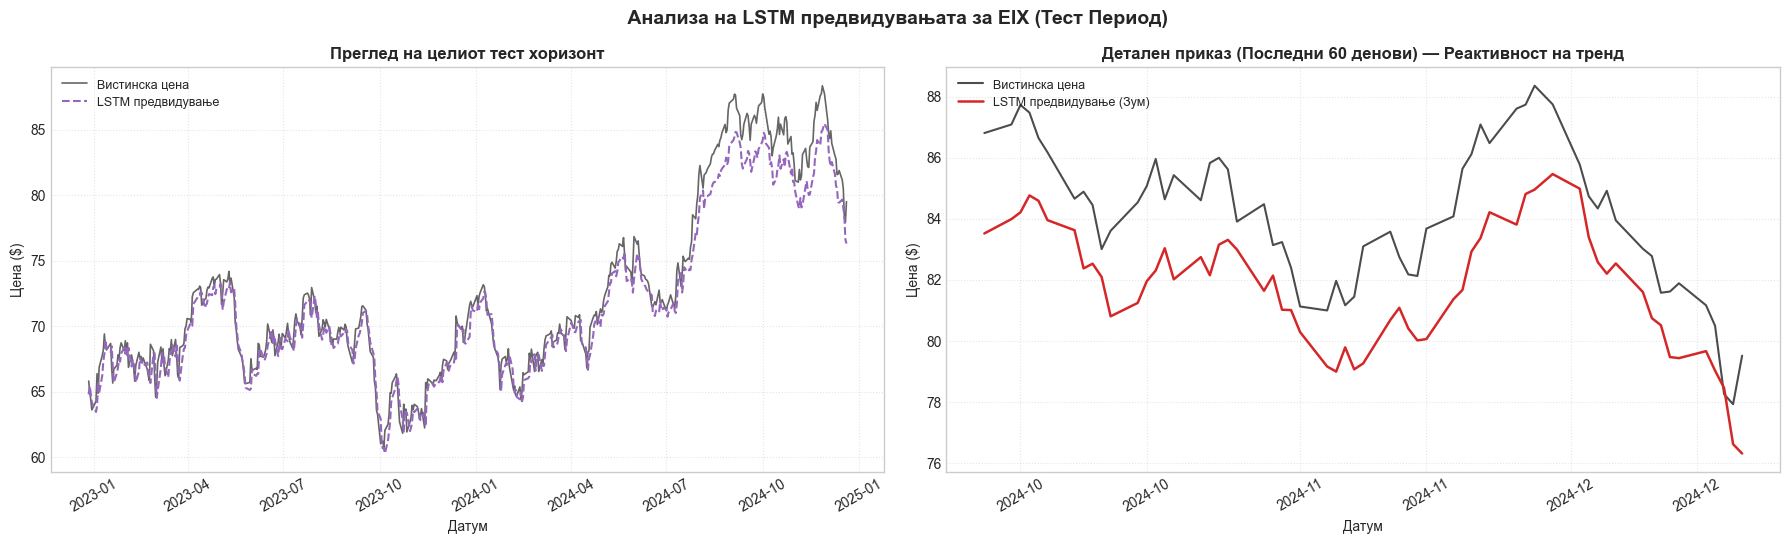

In [189]:

lstm_test_dates = df_ml['Date'].iloc[split_idx:].reset_index(drop=True)


fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))
fig.suptitle(f' Анализа на LSTM предвидувањата за {TICKER} (Тест Период)', fontsize=14, fontweight='bold', y=0.98)


axes[0].plot(lstm_test_dates, y_lstm_actual, color='black', linewidth=1.2, label='Вистинска цена', alpha=0.6)
axes[0].plot(lstm_test_dates, lstm_preds, color='#9467bd', linestyle='--', linewidth=1.5, label='LSTM предвидување')
axes[0].set_title('Преглед на целиот тест хоризонт', fontweight='bold')
axes[0].set_ylabel('Цена ($)')
axes[0].set_xlabel('Датум')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, linestyle=':', alpha=0.5)


zoom_days = 60
axes[1].plot(lstm_test_dates.tail(zoom_days), y_lstm_actual[-zoom_days:], color='black', linewidth=1.5, label='Вистинска цена', alpha=0.7)
axes[1].plot(lstm_test_dates.tail(zoom_days), lstm_preds[-zoom_days:], color='#d62728', linestyle='-', linewidth=1.8, label='LSTM предвидување (Зум)')
axes[1].set_title(f'Детален приказ (Последни {zoom_days} денови) — Реактивност на тренд', fontweight='bold')
axes[1].set_ylabel('Цена ($)')
axes[1].set_xlabel('Датум')
axes[1].legend(fontsize=9, loc='upper left')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## 🏆 11. Финална споредба — сите модели

Финален Извештај и Сортирана Табела

In [190]:

df_final = df_comparison.copy()

print("\n" + "=" * 75)
print("        ФИНАЛЕН ИЗВЕШТАЈ — СПОРЕДБА НА СИТЕ МОДЕЛИ (СОРТИРАНО ПО MAE)")
print("=" * 75)


df_final_sorted = df_final.sort_values(by="MAE ($)")

try:
    display(df_final_sorted)
except NameError:
    print(df_final_sorted)

print("=" * 75)


        ФИНАЛЕН ИЗВЕШТАЈ — СПОРЕДБА НА СИТЕ МОДЕЛИ (СОРТИРАНО ПО MAE)


,MAE ($),RMSE ($),R² Test (%),R² Train (%),MAPE (%),Overfit Gap
Naive Baseline,0.71,0.9,98.25,-,0.99,-
"ARIMA(1, 1, 1)",0.71,0.9,98.25,-,0.99,-
LSTM,1.13,1.45,95.4,-,1.5,-
Random Forest,1.18,1.75,93.31,98.95,1.56,5.64
SVR,1.39,2.05,90.83,98.56,1.81,7.72
XGBoost,1.69,2.5,86.38,98.95,2.18,12.57
KNN,2.09,2.86,82.19,100.0,2.74,17.81


Подготовка за Визуелизација

In [191]:

models_to_plot = list(df_final.index)


mae_vals  = [float(df_final.loc[m, "MAE ($)"]) for m in models_to_plot]
rmse_vals = [float(df_final.loc[m, "RMSE ($)"]) for m in models_to_plot]


colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

print(f" Чекор 2: Подготвени се {len(models_to_plot)} модели за графичка споредба.")

 Чекор 2: Подготвени се 7 модели за графичка споредба.


Генерирање на Финалните Споредбени Графикони

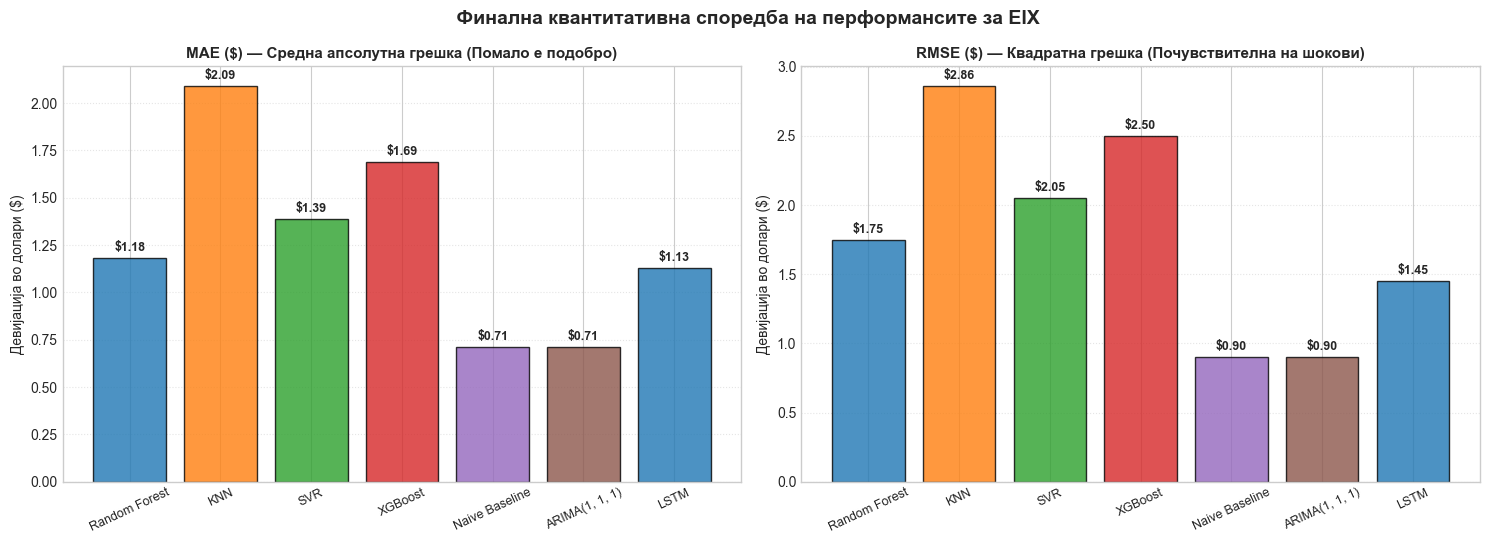

In [192]:


fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle(f' Финална квантитативна споредба на перформансите за {TICKER}', fontsize=14, fontweight='bold', y=0.98)


bar1 = axes[0].bar(models_to_plot, mae_vals, color=colors[:len(models_to_plot)], edgecolor='black', alpha=0.8)
axes[0].set_title('MAE ($) — Средна апсолутна грешка (Помало е подобро)', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Девијација во долари ($)')
axes[0].tick_params(axis='x', rotation=25, labelsize=9)
axes[0].grid(True, linestyle=':', alpha=0.5, axis='y')


for bar, v in zip(bar1, mae_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(mae_vals)*0.01), f'${v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')


bar2 = axes[1].bar(models_to_plot, rmse_vals, color=colors[:len(models_to_plot)], edgecolor='black', alpha=0.8)
axes[1].set_title('RMSE ($) — Квадратна грешка (Почувствителна на шокови)', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Девијација во долари ($)')
axes[1].tick_params(axis='x', rotation=25, labelsize=9)
axes[1].grid(True, linestyle=':', alpha=0.5, axis='y')


for bar, v in zip(bar2, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(rmse_vals)*0.01), f'${v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

Логика за Прогласување Победник и Економски Заклучок

In [193]:

baseline_str = "Naive Baseline" if "Naive Baseline" in df_final.index else "Naïve Baseline"
df_only_models = df_final.drop(baseline_str)


winner_name = df_only_models["MAE ($)"].astype(float).idxmin()
winner_mae = df_final.loc[winner_name, 'MAE ($)']
baseline_mae = df_final.loc[baseline_str, 'MAE ($)']

print("\n" + "=" * 75)
print(f" СТРУЧЕН ЗАКЛУЧОК ОД АНАЛИЗАТА:")
print(f"   Најдобар резултат со најмало отстапување покажа: {winner_name} (MAE = ${winner_mae})")
print("-" * 75)


if float(winner_mae) < float(baseline_mae):
    improvement = ((float(baseline_mae) - float(winner_mae)) / float(baseline_mae)) * 100
    print(f"    УСПЕХ: {winner_name} успеа да ја надмине Наивната базна линија")
    print(f"             за {improvement:.2f}% во прецизноста!")
    print("             Тоа докажува дека моделот успеал да извлече профитабилни")
    print("             шаблони кои ги надминуваат краткорочните пазарни случајности.")
else:
    print(f"    РЕЗУЛТАТ: Ниту еден модел не успеа значајно да ја победи базната линија (Naive Baseline = ${baseline_mae}).")
    print("                Ова е класичен доказ за 'Хипотезата за ефикасен пазар' (Efficient Market Hypothesis),")
    print("                која налага дека утрешната цена најдобро се предвидува со денешната, а сите")
    print("                останати обиди со комплексни алгоритми често резултираат со задоцнети сигнали (lag).")
print("=" * 75)


 СТРУЧЕН ЗАКЛУЧОК ОД АНАЛИЗАТА:
   Најдобар резултат со најмало отстапување покажа: ARIMA(1, 1, 1) (MAE = $0.71)
---------------------------------------------------------------------------
    РЕЗУЛТАТ: Ниту еден модел не успеа значајно да ја победи базната линија (Naive Baseline = $0.71).
                Ова е класичен доказ за 'Хипотезата за ефикасен пазар' (Efficient Market Hypothesis),
                која налага дека утрешната цена најдобро се предвидува со денешната, а сите
                останати обиди со комплексни алгоритми често резултираат со задоцнети сигнали (lag).


### 11.1 Важност на карактеристики (XGBoost)

Извлекување на податоци и пресметка

In [194]:

xgb_model = all_models["XGBoost"]
feat_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

print(" Чекор 1: Вредностите за Feature Importance се успешно извлечени од XGBoost.")

 Чекор 1: Вредностите за Feature Importance се успешно извлечени од XGBoost.


Хоризонтален Баричен График (Визуелизација)

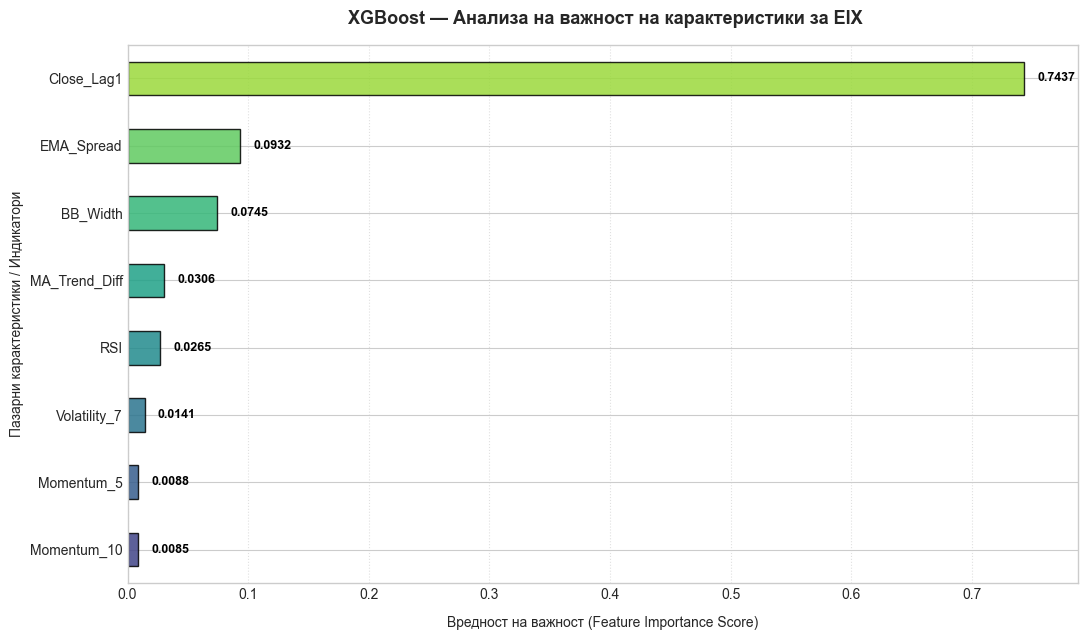

In [195]:


fig, ax = plt.subplots(figsize=(11, 6.5))


colors_bar = plt.cm.viridis(np.linspace(0.2, 0.85, len(feat_imp)))
feat_imp.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='black', alpha=0.85)

ax.set_title(f' XGBoost — Анализа на важност на карактеристики за {TICKER}', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Вредност на важност (Feature Importance Score)', fontsize=10, labelpad=10)
ax.set_ylabel('Пазарни карактеристики / Индикатори', fontsize=10)

max_val = feat_imp.max()
offset = max_val * 0.015

for i, v in enumerate(feat_imp.values):
    ax.text(v + offset, i, f'{v:.4f}', va='center', ha='left', fontsize=9, fontweight='bold', color='black')


ax.grid(True, linestyle=':', alpha=0.6, axis='x')
ax.set_xlim(0, max_val + (offset * 4))

plt.tight_layout()
plt.show()

## 12. Анализа на перформансите во тест периодот (Јануари 2024)

Селекција на победник, Филтрирање и Метрики

In [196]:

def predict_future_recursive(model, scaler, feature_cols, last_known_history, steps=20):
    history_df = last_known_history.tail(60).copy().reset_index(drop=True)
    future_predictions = []
    current_date = pd.to_datetime(history_df['Date'].iloc[-1])

    for step in range(steps):
        next_date = current_date + pd.Timedelta(days=1)
        if next_date.weekday() >= 5:
            next_date += pd.Timedelta(days=2 if next_date.weekday() == 5 else 1)
        current_date = next_date

        last_close = history_df['Close'].iloc[-1]
        new_row = {col: history_df[col].iloc[-1] for col in history_df.columns if col not in ['Date']}
        new_row['Date'] = next_date
        new_row['Close'] = last_close  

        history_df = pd.concat([history_df, pd.DataFrame([new_row])], ignore_index=True)
       
        df_temp_features = create_features_clean(history_df)

        X_next = df_temp_features[feature_cols].iloc[[-1]]
        X_next_df = pd.DataFrame(X_next, columns=feature_cols)

        X_next_scaled = scaler.transform(X_next_df)
        pred_close = model.predict(X_next_scaled)[0]

        
        history_df.loc[history_df.index[-1], 'Close'] = pred_close
        future_predictions.append(pred_close)

    return future_predictions

print("Функцијата `predict_future_recursive` е дефинирана (целосно ажурирање на сите карактеристики на секој чекор).")

Функцијата `predict_future_recursive` е дефинирана (целосно ажурирање на сите карактеристики на секој чекор).


In [197]:


test_df_full = df_ml.iloc[split_idx:].copy()


if winner_name == "LSTM":
    test_df_full['Predicted'] = lstm_preds
elif winner_name == ARIMA_LABEL:
    test_df_full['Predicted'] = arima_preds.values
else:
   
    test_df_full['Predicted'] = all_models[winner_name].predict(X_test_scaled)


jan_mask = (test_df_full['Date'] >= '2024-01-01') & (test_df_full['Date'] <= '2024-01-31')
jan_df   = test_df_full[jan_mask]


if jan_df.empty:
    print(" Нема податоци за Јануари 2024 во тест сетот.")
    print(f"   Актуелен тест период: {test_df_full['Date'].iloc[0].date()} → {test_df_full['Date'].iloc[-1].date()}")
else:
   
    jan_report = pd.DataFrame({
        'Датум': jan_df['Date'].dt.strftime('%Y-%m-%d'),
        'Вистинска Цена ($)': jan_df['Close'].round(2).values,
        'Предвидена Цена ($)': jan_df['Predicted'].round(2).values,
    })

    
    jan_report['Грешка ($)']         = (jan_report['Предвидена Цена ($)'] - jan_report['Вистинска Цена ($)']).round(2)
    jan_report['Апс. Грешка ($)']    = jan_report['Грешка ($)'].abs()
    jan_report['Точност (%)']        = (100 - jan_report['Апс. Грешка ($)'] / jan_report['Вистинска Цена ($)'] * 100).round(2)

    
    jan_mae   = jan_report['Апс. Грешка ($)'].mean()
    jan_mape  = (jan_report['Апс. Грешка ($)'] / jan_report['Вистинска Цена ($)'] * 100).mean()
    jan_acc   = jan_report['Точност (%)'].mean()

    print(f" Чекор 1: Успешно генерирани девијации за Јануари 2024 со моделот {winner_name}.")

 Чекор 1: Успешно генерирани девијации за Јануари 2024 со моделот ARIMA(1, 1, 1).


Печатење на Табеларниот Извештај (Ден-по-Ден)

In [198]:


print("=" * 75)
print(f"  ДЕТАЛЕН ИЗВЕШТАЈ ДЕН-ПО-ДЕН: ЈАНУАРИ 2024 (Модел: {winner_name})")
print("=" * 75)

try:
    display(jan_report.reset_index(drop=True))
except NameError:
    print(jan_report.reset_index(drop=True))

print(f"\n ПРОСЕЧНИ ПЕРФОРМАНСИ ЗА МЕСЕЦОТ:")
print(f"   • Просечна апсолутна грешка (MAE):  ${jan_mae:.2f}")
print(f"   • Просечна релативна грешка (MAPE): {jan_mape:.2f}%")
print(f"   • Системска точност на предвидување: {jan_acc:.2f}%")
print("=" * 75)

  ДЕТАЛЕН ИЗВЕШТАЈ ДЕН-ПО-ДЕН: ЈАНУАРИ 2024 (Модел: ARIMA(1, 1, 1))


,Датум,Вистинска Цена ($),Предвидена Цена ($),Грешка ($),Апс. Грешка ($),Точност (%)
0,2024-01-02,72.34,71.49,-0.85,0.85,98.82
1,2024-01-03,71.58,72.32,0.74,0.74,98.97
2,2024-01-04,72.29,71.60,-0.69,0.69,99.05
3,2024-01-05,72.57,72.27,-0.30,0.30,99.59
4,2024-01-08,73.17,72.56,-0.61,0.61,99.17
5,2024-01-09,73.02,73.15,0.13,0.13,99.82
6,2024-01-10,72.33,73.02,0.69,0.69,99.05
7,2024-01-11,71.17,72.35,1.18,1.18,98.34
8,2024-01-12,71.36,71.20,-0.16,0.16,99.78
9,2024-01-16,70.17,71.36,1.19,1.19,98.30



 ПРОСЕЧНИ ПЕРФОРМАНСИ ЗА МЕСЕЦОТ:
   • Просечна апсолутна грешка (MAE):  $0.70
   • Просечна релативна грешка (MAPE): 1.02%
   • Системска точност на предвидување: 98.99%


Напредна Микро Визуелизација

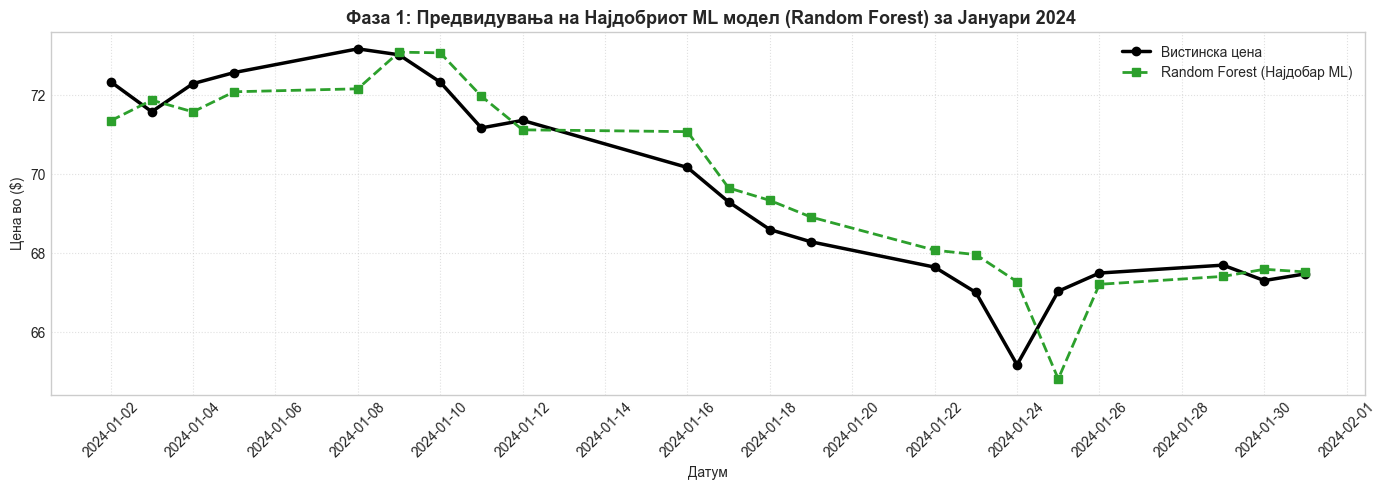

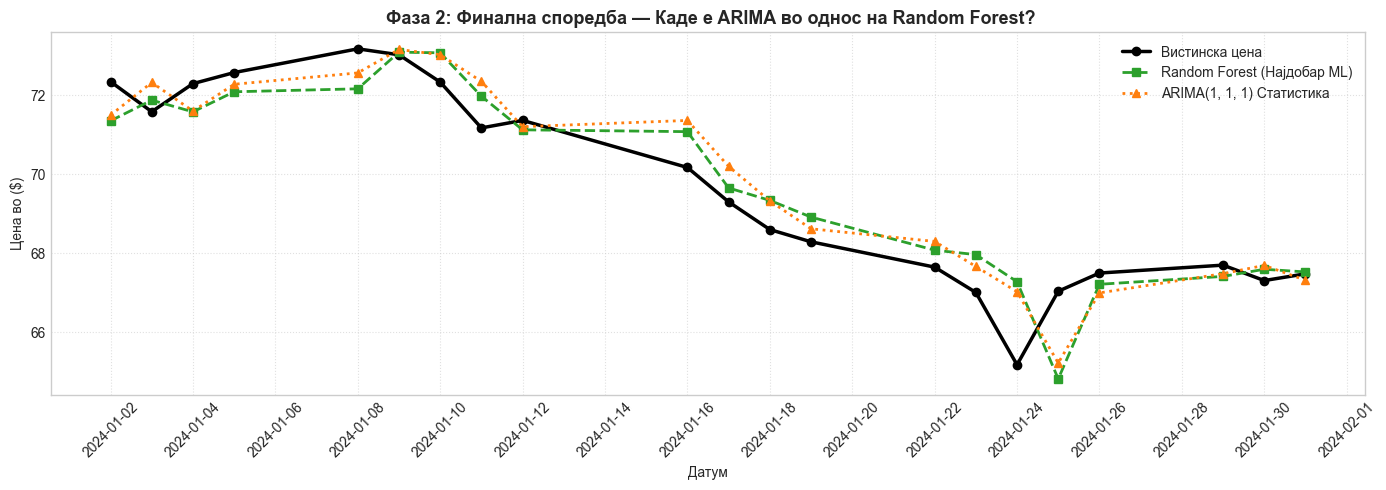

In [199]:

test_df_jan = df_ml.iloc[split_idx:].copy()


test_df_jan['RF_Predictions'] = all_models["Random Forest"].predict(X_test_scaled)
test_df_jan['ARIMA_Predictions'] = arima_preds.values


jan_mask = (test_df_jan['Date'] >= '2024-01-01') & (test_df_jan['Date'] <= '2024-01-31')
jan_plot_df = test_df_jan[jan_mask].copy()


plt.figure(figsize=(14, 5))
plt.plot(jan_plot_df['Date'], jan_plot_df['Close'], marker='o', color='black', linewidth=2.5, label='Вистинска цена ')
plt.plot(jan_plot_df['Date'], jan_plot_df['RF_Predictions'], marker='s', color='#2ca02c', linestyle='--', linewidth=2, label='Random Forest (Најдобар ML)')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)
plt.title(' Фаза 1: Предвидувања на Најдобриот ML модел (Random Forest) за Јануари 2024', fontsize=13, fontweight='bold')
plt.xlabel('Датум')
plt.ylabel('Цена во ($)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 5))
plt.plot(jan_plot_df['Date'], jan_plot_df['Close'], marker='o', color='black', linewidth=2.5, label='Вистинска цена ')
plt.plot(jan_plot_df['Date'], jan_plot_df['RF_Predictions'], marker='s', color='#2ca02c', linestyle='--', linewidth=2, label='Random Forest (Најдобар ML)')
plt.plot(jan_plot_df['Date'], jan_plot_df['ARIMA_Predictions'], marker='^', color='#ff7f0e', linestyle=':', linewidth=2, label=f'{ARIMA_LABEL} Статистика')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)
plt.title(' Фаза 2: Финална споредба — Каде е ARIMA во однос на Random Forest?', fontsize=13, fontweight='bold')
plt.xlabel('Датум')
plt.ylabel('Цена во ($)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Стрес-тест за Јануари 2025 година

 ГЕНЕРИРАЊЕ НА ПРЕДВИДУВАЊА ЗА СЛЕДНИОТ МЕСЕЦ (EIX)
   Последен познат датум: 2024-12-20
   Предвидување за:      2024-12-23 → 2025-01-17


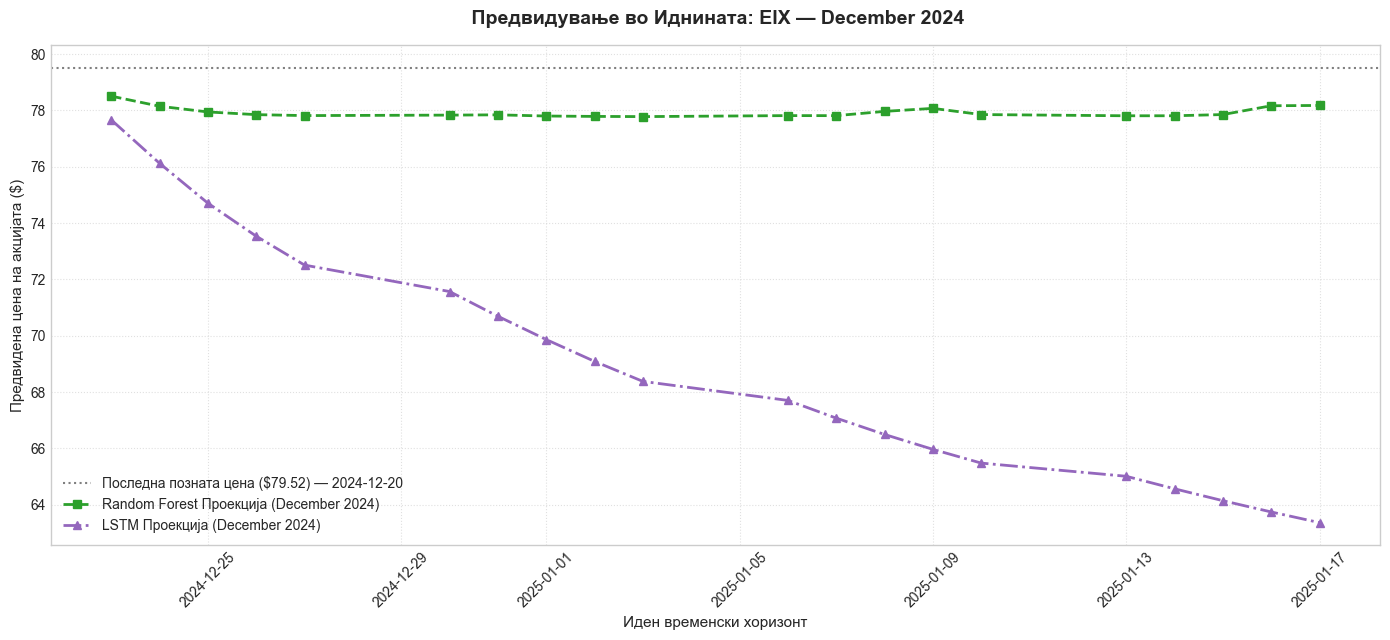

 Проекцијата за December 2024 е успешно генерирана со вистинските модели!


In [200]:

print("=" * 65)
print(f" ГЕНЕРИРАЊЕ НА ПРЕДВИДУВАЊА ЗА СЛЕДНИОТ МЕСЕЦ ({TICKER})")
print("=" * 65)


last_date = df_ml['Date'].iloc[-1]
future_start = last_date + pd.tseries.offsets.BDay(1)
future_dates = pd.date_range(start=future_start, periods=20, freq='B')
future_label = future_dates[0].strftime('%B %Y')

print(f"   Последен познат датум: {last_date.date()}")
print(f"   Предвидување за:      {future_dates[0].date()} → {future_dates[-1].date()}")

last_close = df_ml['Close'].iloc[-1]


rf_predictions_future = predict_future_recursive(
    model=all_models[best_ml_name],
    scaler=scaler,
    feature_cols=FEATURE_COLS,
    last_known_history=df_ml,
    steps=20
)

lstm_window = df_ml['Close'].values[-LSTM_LOOKBACK:].reshape(-1, 1)
lstm_window_scaled = lstm_scaler.transform(lstm_window)

lstm_predictions_future = []
current_window = lstm_window_scaled.copy()

for i in range(20):
    x_input = current_window.reshape(1, LSTM_LOOKBACK, 1)
    pred_scaled = lstm_model.predict(x_input, verbose=0)
    pred_price = lstm_scaler.inverse_transform(pred_scaled)[0, 0]
    lstm_predictions_future.append(pred_price)

   
    new_val = pred_scaled[0, 0]
    current_window = np.roll(current_window, -1, axis=0)
    current_window[-1, 0] = new_val


plt.figure(figsize=(14, 6.5))

plt.axhline(y=last_close, color='gray', linestyle=':',
            label=f'Последна позната цена (${last_close:.2f}) — {last_date.date()}')

plt.plot(future_dates, rf_predictions_future, marker='s', color='#2ca02c', linestyle='--', linewidth=2,
         label=f'{best_ml_name} Проекција ({future_label})')

plt.plot(future_dates, lstm_predictions_future, marker='^', color='#9467bd', linestyle='-.', linewidth=2,
         label=f'LSTM Проекција ({future_label})')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.title(f' Предвидување во Иднината: {TICKER} — {future_label}', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Иден временски хоризонт', fontsize=11)
plt.ylabel('Предвидена цена на акцијата ($)', fontsize=11)
plt.legend(fontsize=10, loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print(f" Проекцијата за {future_label} е успешно генерирана со вистинските модели!")
print("=" * 65)